# Capstone Project

In [1]:
%reset -f

In [2]:
# IMPORTING LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.gaussian_process.kernels import RBF
from scipy.optimize import minimize
from sklearn.gaussian_process.kernels import Matern
import matplotlib.colors as mcolors
from scipy.optimize import minimize
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.svm import SVC
import tensorflow as tf
from tensorflow import keras

np.random.seed(42)
tf.random.set_seed(42)

I0000 00:00:1782238955.282202  400177 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782238956.970813  400177 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/omkarsjoshi/miniconda3/envs/ICL/lib/python3.11/site-packages/requests/__init__.py:92: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [3]:
# LOADING FUNCTION VALUES
def load_function(fn_num):
    X_read = np.load(f'initial_data_5/function_{fn_num}/initial_inputs.npy')
    y_read = np.load(f'initial_data_5/function_{fn_num}/initial_outputs.npy')
    cols = [f'x{i+1}' for i in range(X_read.shape[1])]
    X = pd.DataFrame(X_read, columns=cols)
    y = pd.Series(y_read, name='y')
    return X, y

X1, y1 = load_function(1)
X2, y2 = load_function(2)
X3, y3 = load_function(3)
X4, y4 = load_function(4)
X5, y5 = load_function(5)
X6, y6 = load_function(6)
X7, y7 = load_function(7)
X8, y8 = load_function(8)

all_X = [X1, X2, X3, X4, X5, X6, X7, X8]
all_y = [y1, y2, y3, y4, y5, y6, y7, y8]

In [4]:
# MAIN FUNCTIONS (ACQUISITION, BO)
# ── Acquisition functions ────────────────────────────────────────────────────

def acq_PI(mu, sigma, y_max, y_vals, xi_frac=0.01):
    y_vals = np.asarray(y_vals).ravel()
    xi = float(xi_frac * max(y_vals.std(), 1e-6))
    z = (mu - y_max - xi) / (sigma + 1e-9)
    return norm.cdf(z)

def acq_EI(mu, sigma, y_max, y_vals, xi_frac=0.01):
    y_vals = np.asarray(y_vals).ravel()
    xi = float(xi_frac * max(y_vals.std(), 1e-6))
    z = (mu - y_max - xi) / (sigma + 1e-9)
    ei = (mu - y_max - xi) * norm.cdf(z) + sigma * norm.pdf(z)
    ei[sigma < 1e-10] = 0
    return ei

def acq_UCB(mu, sigma, y_max, y_vals, t, d=1, delta=0.5):
    beta = min(np.sqrt(2 * np.log(d * t**2 * np.pi**2 / (6 * delta))), 3.0)
    return mu + beta * sigma

def acq_thompson(gp, candidates, random_state=None):
    y_sample = gp.sample_y(candidates, n_samples=1, random_state=random_state)
    return y_sample.ravel()

def acq_MD(X_observed, candidates):
    """Max-distance: farthest candidate from all observed points."""
    dists = np.min(np.linalg.norm(
        candidates[:, None, :] - X_observed[None, :, :], axis=2), axis=1)
    return dists

# ── Bayesian optimisation ────────────────────────────────────────────────────

from scipy.optimize import differential_evolution

def run_bo(fn_num, warp=False, use_ts=False, use_md=False, de_popsize=20, de_maxiter=50):
    X = all_X[fn_num - 1].values
    Y_raw = all_y[fn_num - 1].values
    n_dim = X.shape[1]
    dim_cols = all_X[fn_num - 1].columns.tolist()

    if warp == 'yeo':
        pt = PowerTransformer(method='yeo-johnson')
        Y = pt.fit_transform(Y_raw.reshape(-1, 1)).ravel()
        warp_fn = lambda y, _pt=pt: _pt.inverse_transform([[y]])[0, 0]
    elif warp == 'log':
        Y = np.log1p(Y_raw)
        warp_fn = lambda y: np.expm1(y)
    elif warp == 'sqrt':
        Y = np.sqrt(Y_raw)
        warp_fn = lambda y: y**2
    else:
        Y = Y_raw
        warp_fn = lambda y: y
    pt = None

    y_max = Y.max()

    kernel = Matern(
        length_scale=np.ones(n_dim),
        length_scale_bounds=(1e-3, 10000.0),
        nu=2.5
    )
    gp = GaussianProcessRegressor(
        kernel=kernel,
        alpha = 0.01 if fn_num == 2 else 1e-6,
        n_restarts_optimizer=max(5, 2 * n_dim),
        normalize_y=True
    )
    gp.fit(X, Y)

    bounds = [(1e-6, 0.999999)] * n_dim

    acq_funcs = {
        'EI':  lambda m, s: acq_EI(m, s, y_max, Y),
        'UCB': lambda m, s: acq_UCB(m, s, y_max, Y, t=len(Y), d=n_dim),
        'PI':  lambda m, s: acq_PI(m, s, y_max, Y),
    }

    acq_results = {}

    for acq_name, acq_fn in acq_funcs.items():

        def neg_acq(x):
            # handle both DE's population batches (n_dim, popsize) and
            # the polish step's single point (n_dim,)
            x = np.atleast_2d(x)
            if x.shape[0] == n_dim and x.shape[1] != n_dim:
                x = x.T  # came in as (n_dim, popsize) -> (popsize, n_dim)
            mu, sigma = gp.predict(x, return_std=True)
            scores = -acq_fn(mu, sigma)
            return scores if scores.shape[0] > 1 else scores[0]

        result = differential_evolution(
            neg_acq, bounds,
            vectorized=True,
            updating='deferred',  # explicitly set, suppresses the warning
            popsize=de_popsize,
            maxiter=de_maxiter,
            tol=1e-7,
            seed=42,
            polish=True
        )
        acq_results[acq_name] = np.clip(result.x, 1e-6, 0.999999)

    if use_ts:
        ts_n = 1000
        ts_candidates = np.random.uniform(1e-6, 0.999999, size=(ts_n, n_dim))
        ts_scores = acq_thompson(gp, ts_candidates)
        acq_results['TS'] = np.clip(ts_candidates[np.argmax(ts_scores)], 1e-6, 0.999999)

    if use_md:
        md_n = 10000
        md_candidates = np.random.uniform(1e-6, 0.999999, size=(md_n, n_dim))
        md_scores = acq_MD(X, md_candidates)
        acq_results['MD'] = np.clip(md_candidates[np.argmax(md_scores)], 1e-6, 0.999999)

    rows = []
    for acq_name, x_next in acq_results.items():
        pred_y_warped = float(gp.predict(x_next.reshape(1, -1))[0])
        if warp:
            pred_y = float(warp_fn(pred_y_warped))
        else:
            pred_y = pred_y_warped
        row = {
            'function':     fn_num,
            'dimensions':   n_dim,
            'acquisition':  acq_name,
            'predicted_y':  round(pred_y, 6),
            'y_max_so_far': round(float(Y_raw.max()), 6),
            'submission':   '-'.join([f'{v:.6f}' for v in x_next]),
        }
        for i, col in enumerate(dim_cols):
            row[f'{col}_suggested'] = round(float(x_next[i]), 6)
        rows.append(row)

    return pd.DataFrame(rows), gp

In [5]:
# WARP/STALL/BLIND FUNCTIONS AND RUNNING BO
 
warp_functions = {}  # dict instead of set
stalled_functions = {2}
blind_functions = {1}

all_suggestions = []
gps = {}

for fn in range(1, 9):
    n_dim = all_X[fn - 1].shape[1]
    df_sugg, gp = run_bo(
        fn,
        warp=warp_functions.get(fn, None),
        use_ts=(fn in stalled_functions),
        use_md=(fn in blind_functions)

    )
    all_suggestions.append(df_sugg)
    gps[fn] = gp
    print(f'F{fn} (d={n_dim}) done. Fitted kernel: {gp.kernel_}')

df_all = pd.concat(all_suggestions, ignore_index=True)
print(f'\nTotal rows: {len(df_all)} ({len(df_all)} rows across 8 functions — F1/F2 have TS as 4th acquisition)')
print(df_all[['function','dimensions','acquisition','y_max_so_far','predicted_y']].to_string(index=False))

F1 (d=2) done. Fitted kernel: Matern(length_scale=[0.0468, 0.104], nu=2.5)
F2 (d=2) done. Fitted kernel: Matern(length_scale=[0.0918, 0.0209], nu=2.5)
F3 (d=3) done. Fitted kernel: Matern(length_scale=[0.533, 0.901, 0.17], nu=2.5)
F4 (d=4) done. Fitted kernel: Matern(length_scale=[0.842, 0.688, 0.843, 0.79], nu=2.5)
F5 (d=4) done. Fitted kernel: Matern(length_scale=[0.654, 0.666, 0.927, 1], nu=2.5)
F6 (d=5) done. Fitted kernel: Matern(length_scale=[0.536, 0.729, 1.07, 0.819, 1.11], nu=2.5)


/home/omkarsjoshi/miniconda3/envs/ICL/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 5 of parameter length_scale is close to the specified upper bound 10000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


F7 (d=6) done. Fitted kernel: Matern(length_scale=[0.428, 0.484, 1.2e+03, 0.215, 0.5, 1e+04], nu=2.5)


/home/omkarsjoshi/miniconda3/envs/ICL/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 5 of parameter length_scale is close to the specified upper bound 10000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/omkarsjoshi/miniconda3/envs/ICL/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 7 of parameter length_scale is close to the specified upper bound 10000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


F8 (d=8) done. Fitted kernel: Matern(length_scale=[1.26, 1.85, 0.876, 2.19, 4.68, 1e+04, 1.42, 1e+04], nu=2.5)

Total rows: 26 (26 rows across 8 functions — F1/F2 have TS as 4th acquisition)
 function  dimensions acquisition  y_max_so_far  predicted_y
        1           2          EI      0.000000     0.000110
        1           2         UCB      0.000000    -0.000211
        1           2          PI      0.000000     0.000063
        1           2          MD      0.000000    -0.000257
        2           2          EI      0.611205     0.630481
        2           2         UCB      0.611205     0.368268
        2           2          PI      0.611205     0.634138
        2           2          TS      0.611205     0.282058
        3           3          EI     -0.004334    -0.048058
        3           3         UCB     -0.004334    -0.053178
        3           3          PI     -0.004334    -0.005245
        4           4          EI     -1.217480    -1.285063
        4       

In [6]:
# SELECTING ACQUISITION FUNCTION

rows = []
for fn_num in range(1, 9):
    group = df_all[df_all['function'] == fn_num]
    if fn_num in blind_functions and 'MD' in group['acquisition'].values:
        row = group[group['acquisition'] == 'MD'].iloc[0]
    elif fn_num in stalled_functions and 'TS' in group['acquisition'].values:
        row = group[group['acquisition'] == 'TS'].iloc[0]
    else:
        row = group.sort_values('predicted_y', ascending=False).iloc[0]
    rows.append(row.to_dict())

df_best = pd.DataFrame(rows)[['function', 'dimensions', 'acquisition', 'y_max_so_far', 'predicted_y', 'submission']]
df_best = df_best.reset_index(drop=True)
df_best.index = range(1, 9)
df_best.index.name = 'function'

df_best['x_next'] = df_best['submission'].apply(
    lambda s: [float(v) for v in s.split('-')]
)

print('Best acquisition per function (by predicted_y):')
print(df_best.to_string())
print('\n'.join(df_best['submission'].values))

for fn_num, row in df_best.iterrows():
    dims = all_X[fn_num - 1].columns.tolist()
    coords = dict(zip(dims, row['x_next']))
    print(f"F{fn_num}: {coords}")

Best acquisition per function (by predicted_y):
          function  dimensions acquisition  y_max_so_far  predicted_y                                                               submission                                                                   x_next
function                                                                                                                                                                                                               
1                1           2          MD      0.000000    -0.000257                                                        0.994653-0.996066                                                     [0.994653, 0.996066]
2                2           2          TS      0.611205     0.282058                                                        0.068207-0.078298                                                     [0.068207, 0.078298]
3                3           3          PI     -0.004334    -0.005245                   

In [8]:
# ── GUIDING MODELS: SVM FEASIBILITY + NN SENSITIVITY ─────────────────────────
#
# Neither model touches the GP or the BO loop directly.
# They produce two artefacts used downstream:
#   guide_svms[fn]    → trained SVC for P(promising | x) overlay
#   guide_nn_imp[fn]  → per-dimension sensitivity scores (for ARD init & plots)

guide_svms   = {}   # fn_num → fitted SVC
guide_nn_imp = {}   # fn_num → np.array of shape (n_dim,), normalised to [0,1]

for fn_num in range(1, 9):
    X_raw = all_X[fn_num - 1].values
    y_raw = all_y[fn_num - 1].values
    n_dim = X_raw.shape[1]
    n     = len(y_raw)

    scaler  = StandardScaler()
    X_scaled = scaler.fit_transform(X_raw)

    # ── SVM feasibility classifier ────────────────────────────────────────────
    # Label top-quartile observations as "promising" (1), rest as (0).
    # With very few points (f1/f2: n=13) this is the most data-efficient guide.
    threshold  = np.percentile(y_raw, 75)
    labels_svm = (y_raw >= threshold).astype(int)

    # Fallback: if all labels identical (degenerate landscape), skip SVM
    if labels_svm.sum() < 2 or labels_svm.sum() > n - 2:
        guide_svms[fn_num] = None
        print(f'F{fn_num}: SVM skipped (degenerate labels)')
    else:
        svm = SVC(kernel='rbf', probability=True, C=1.0, gamma='scale',
                  random_state=42)
        svm.fit(X_scaled, labels_svm)
        # Store scaler alongside so prediction is consistent
        svm._guide_scaler = scaler
        guide_svms[fn_num] = svm
        print(f'F{fn_num}: SVM fitted | promising threshold={threshold:.4f}')

# ── NN sensitivity (gradient-based via TensorFlow) ────────────────────────
    # Post-hoc diagnostic only — validates GP ARD, does not influence BO
    min_n_for_nn = 4 * n_dim
    if n < min_n_for_nn:
        guide_nn_imp[fn_num] = np.ones(n_dim) / n_dim
        print(f'F{fn_num}: NN skipped (n={n} < {min_n_for_nn}), using uniform sensitivity')
    else:
        hidden = max(8, n_dim * 2)

        nn = keras.Sequential([
            keras.Input(shape=(n_dim,)),                          # fixes warning
            keras.layers.Dense(hidden, activation='relu',
                               kernel_regularizer=keras.regularizers.l2(0.01)),
            keras.layers.Dense(hidden // 2, activation='relu',
                               kernel_regularizer=keras.regularizers.l2(0.01)),
            keras.layers.Dense(1)
        ])
        nn.compile(optimizer='adam', loss='mse')

        early_stop = keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=20,          # was 30
            restore_best_weights=True
        )
        nn.fit(
            X_scaled, y_raw,
            epochs=200,                               # was 500
            batch_size=max(4, n // 5),
            validation_split=0.2,
            callbacks=[early_stop],
            verbose=0
        )

        X_tensor = tf.constant(X_scaled, dtype=tf.float32)
        with tf.GradientTape() as tape:
            tape.watch(X_tensor)
            y_pred = nn(X_tensor, training=False)
        grads = tape.gradient(y_pred, X_tensor).numpy()
        sensitivities = np.mean(np.abs(grads), axis=0)

        s_range = sensitivities.max() - sensitivities.min()
        if s_range < 1e-12:
            guide_nn_imp[fn_num] = np.ones(n_dim) / n_dim
        else:
            guide_nn_imp[fn_num] = (sensitivities - sensitivities.min()) / s_range

        print(f'F{fn_num}: NN sensitivity = {np.round(guide_nn_imp[fn_num], 3)}')
print('\nGuiding models ready.')

F1: SVM fitted | promising threshold=0.0000
F1: NN sensitivity = [1. 0.]
F2: SVM fitted | promising threshold=0.5122
F2: NN sensitivity = [0. 1.]
F3: SVM fitted | promising threshold=-0.0417
F3: NN sensitivity = [0.927 0.    1.   ]
F4: SVM fitted | promising threshold=-11.5993
F4: NN sensitivity = [1.    0.085 0.331 0.   ]
F5: SVM fitted | promising threshold=374.7583
F5: NN sensitivity = [0.565 0.102 0.    1.   ]
F6: SVM fitted | promising threshold=-0.9091
F6: NN sensitivity = [0.451 0.    1.    0.097 0.228]
F7: SVM fitted | promising threshold=0.5512
F7: NN sensitivity = [0.527 0.221 0.994 1.    0.723 0.   ]
F8: SVM fitted | promising threshold=8.8209
F8: NN sensitivity = [0.088 0.546 0.469 0.402 1.    0.    0.767 0.797]

Guiding models ready.


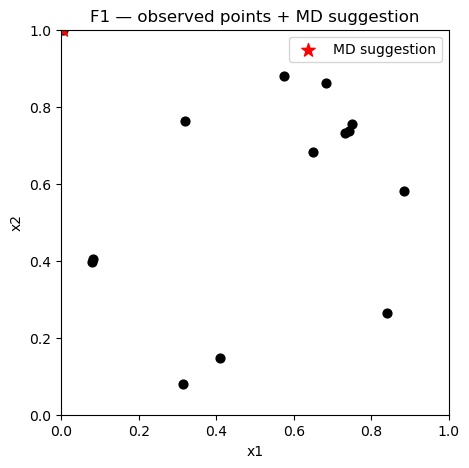

In [9]:
# VISUALISING MAX DISTANCE FOR F1

X1 = all_X[0].values
plt.figure(figsize=(5,5))
plt.scatter(X1[:,0], X1[:,1], c='black', s=40)
plt.scatter(0.003919, 0.999460, c='red', s=100, marker='*', label='MD suggestion')
plt.xlim(0,1); plt.ylim(0,1)
plt.xlabel('x1'); plt.ylabel('x2')
plt.legend()
plt.title('F1 — observed points + MD suggestion')
plt.show()

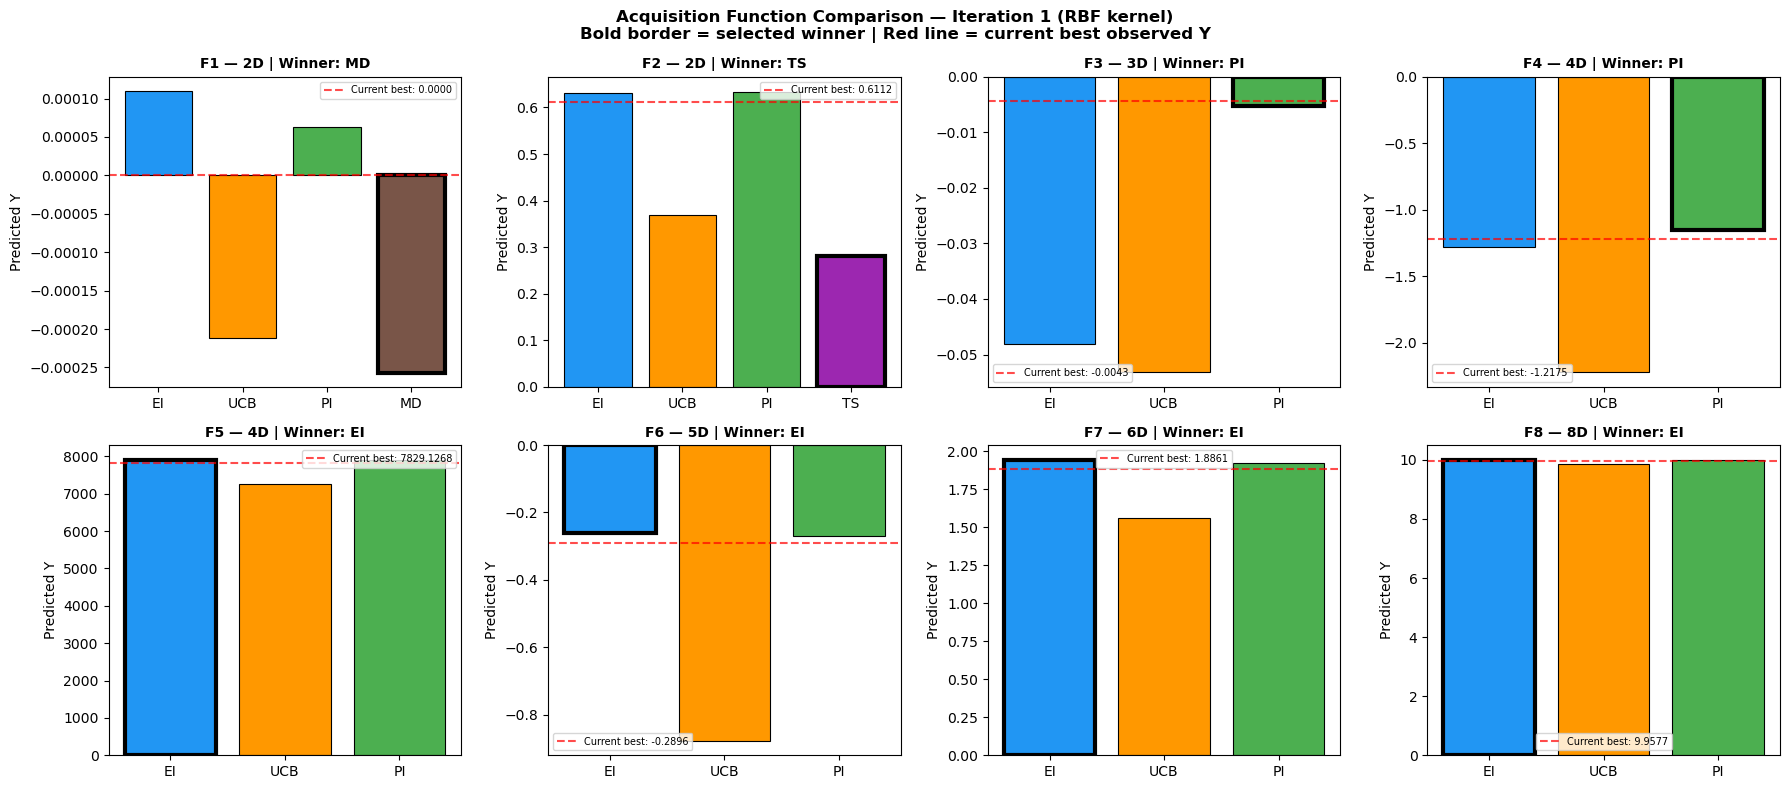

In [10]:
# COMPARING ACQUISITION FUNCTIONS
 
colours = {'EI': '#2196F3', 'UCB': '#FF9800', 'PI': '#4CAF50', 'TS': '#9C27B0', 'MD': '#795548'}
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for fn in range(1, 9):
    ax = axes[fn - 1]
    df_fn = df_all[df_all['function'] == fn]
    winner = df_best.iloc[fn - 1]['acquisition']
    y_current_best = df_best.iloc[fn - 1]['y_max_so_far']

    acq_names   = df_fn['acquisition'].tolist()
    pred_ys     = df_fn['predicted_y'].tolist()
    bar_cols    = [colours[a] for a in acq_names]
    edge_widths = [3 if a == winner else 0.8 for a in acq_names]

    ax.bar(acq_names, pred_ys, color=bar_cols,
           edgecolor='black', linewidth=edge_widths)
    ax.axhline(y_current_best, color='red', linestyle='--',
               alpha=0.7, label=f'Current best: {y_current_best:.4f}')
    ax.set_title(
        f'F{fn} — {all_X[fn-1].shape[1]}D | Winner: {winner}',
        fontsize=10, fontweight='bold'
    )
    ax.set_ylabel('Predicted Y')
    ax.legend(fontsize=7)

fig.suptitle(
    'Acquisition Function Comparison — Iteration 1 (RBF kernel)\n'
    'Bold border = selected winner | Red line = current best observed Y',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

F1: 4 suggestion rows, cols: ['function', 'dimensions', 'acquisition', 'predicted_y', 'y_max_so_far', 'submission', 'x1_suggested', 'x2_suggested', 'x3_suggested', 'x4_suggested', 'x5_suggested', 'x6_suggested', 'x7_suggested', 'x8_suggested']


<positron-console-cell-11>:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


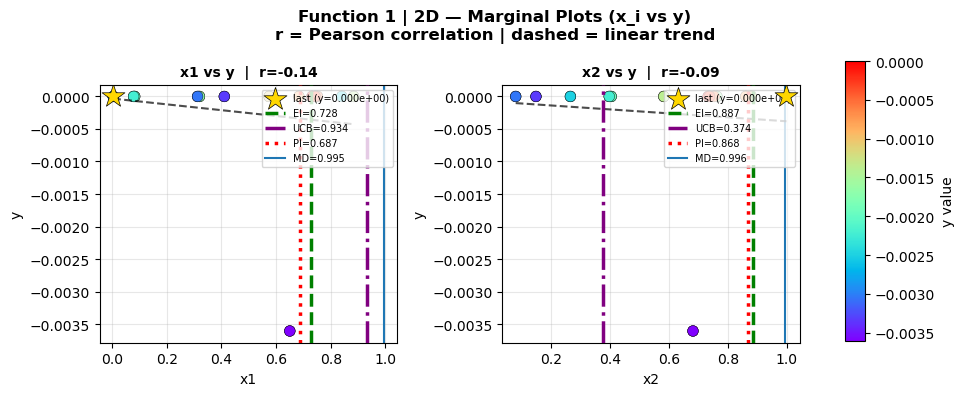

F2: 4 suggestion rows, cols: ['function', 'dimensions', 'acquisition', 'predicted_y', 'y_max_so_far', 'submission', 'x1_suggested', 'x2_suggested', 'x3_suggested', 'x4_suggested', 'x5_suggested', 'x6_suggested', 'x7_suggested', 'x8_suggested']


<positron-console-cell-11>:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


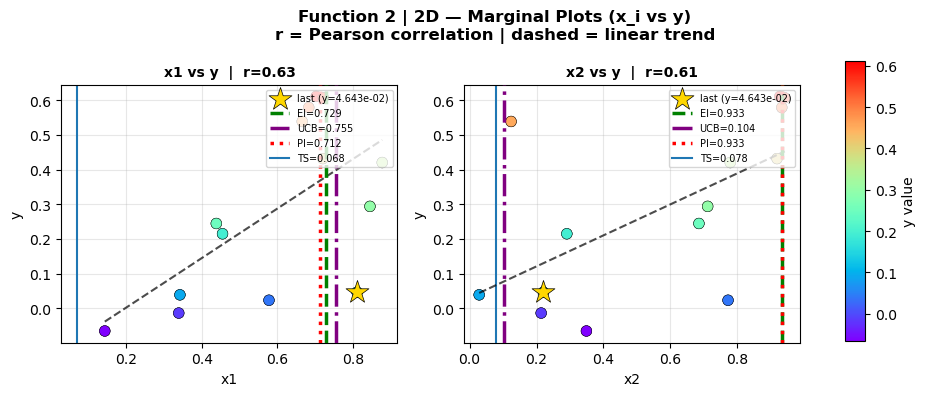

F3: 3 suggestion rows, cols: ['function', 'dimensions', 'acquisition', 'predicted_y', 'y_max_so_far', 'submission', 'x1_suggested', 'x2_suggested', 'x3_suggested', 'x4_suggested', 'x5_suggested', 'x6_suggested', 'x7_suggested', 'x8_suggested']


<positron-console-cell-11>:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


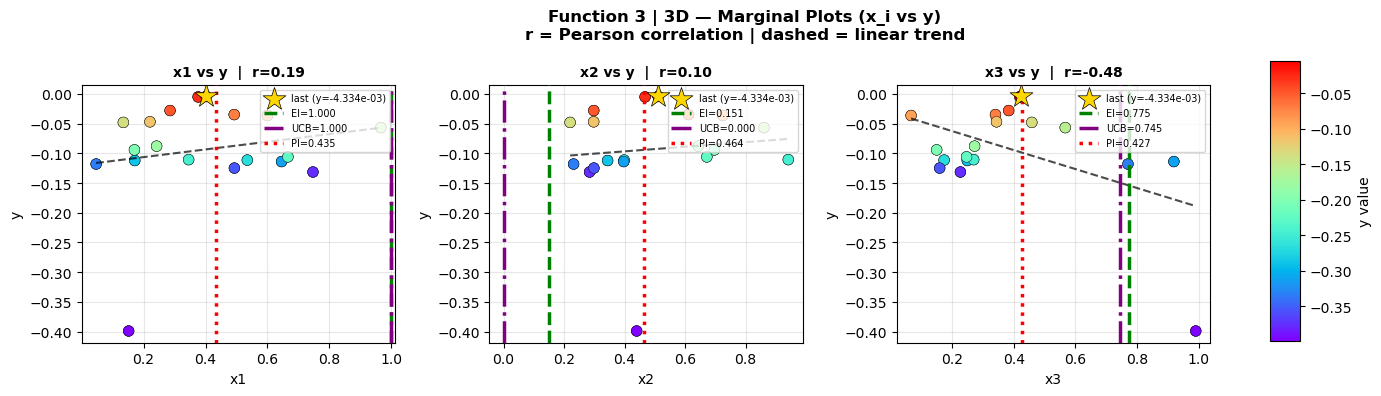

F4: 3 suggestion rows, cols: ['function', 'dimensions', 'acquisition', 'predicted_y', 'y_max_so_far', 'submission', 'x1_suggested', 'x2_suggested', 'x3_suggested', 'x4_suggested', 'x5_suggested', 'x6_suggested', 'x7_suggested', 'x8_suggested']


<positron-console-cell-11>:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


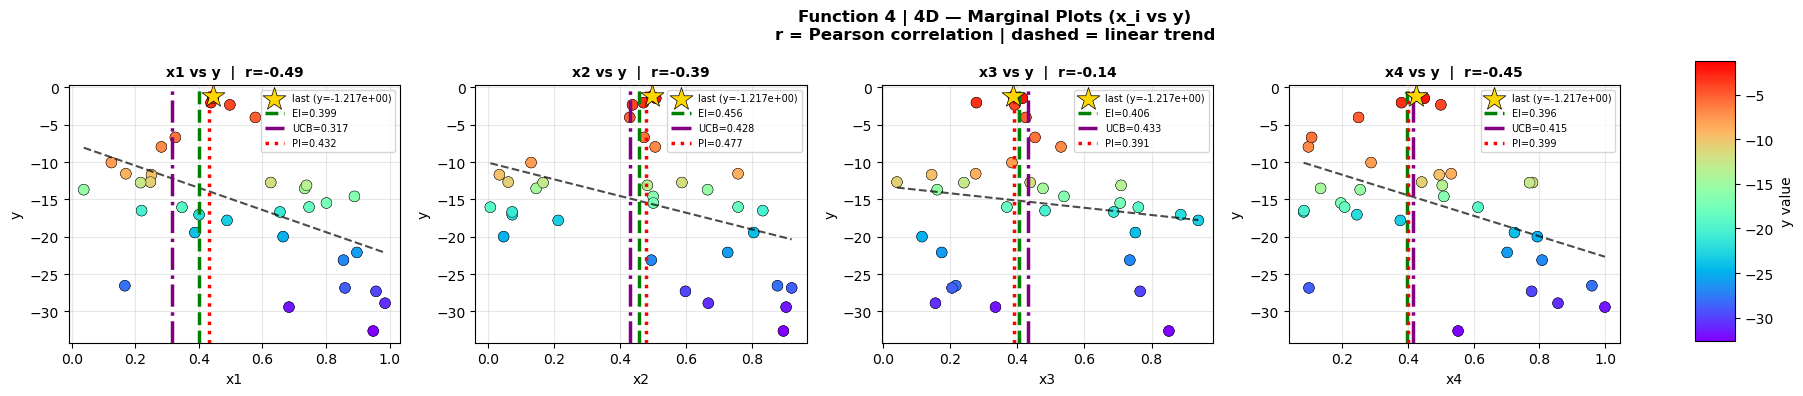

F5: 3 suggestion rows, cols: ['function', 'dimensions', 'acquisition', 'predicted_y', 'y_max_so_far', 'submission', 'x1_suggested', 'x2_suggested', 'x3_suggested', 'x4_suggested', 'x5_suggested', 'x6_suggested', 'x7_suggested', 'x8_suggested']


<positron-console-cell-11>:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


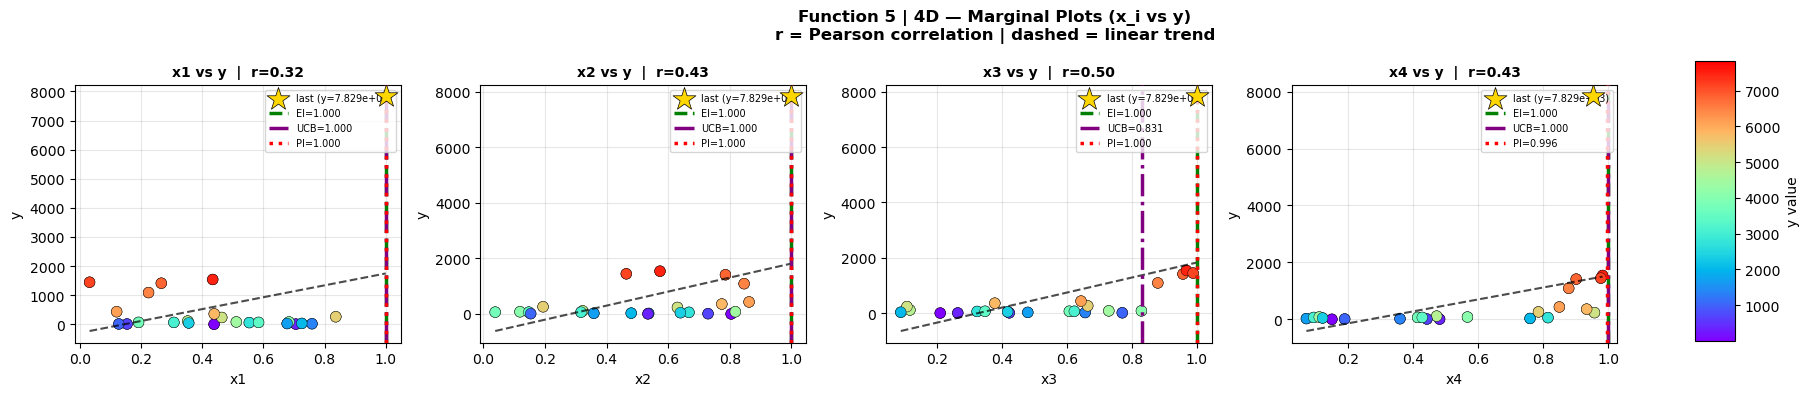

F6: 3 suggestion rows, cols: ['function', 'dimensions', 'acquisition', 'predicted_y', 'y_max_so_far', 'submission', 'x1_suggested', 'x2_suggested', 'x3_suggested', 'x4_suggested', 'x5_suggested', 'x6_suggested', 'x7_suggested', 'x8_suggested']


<positron-console-cell-11>:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


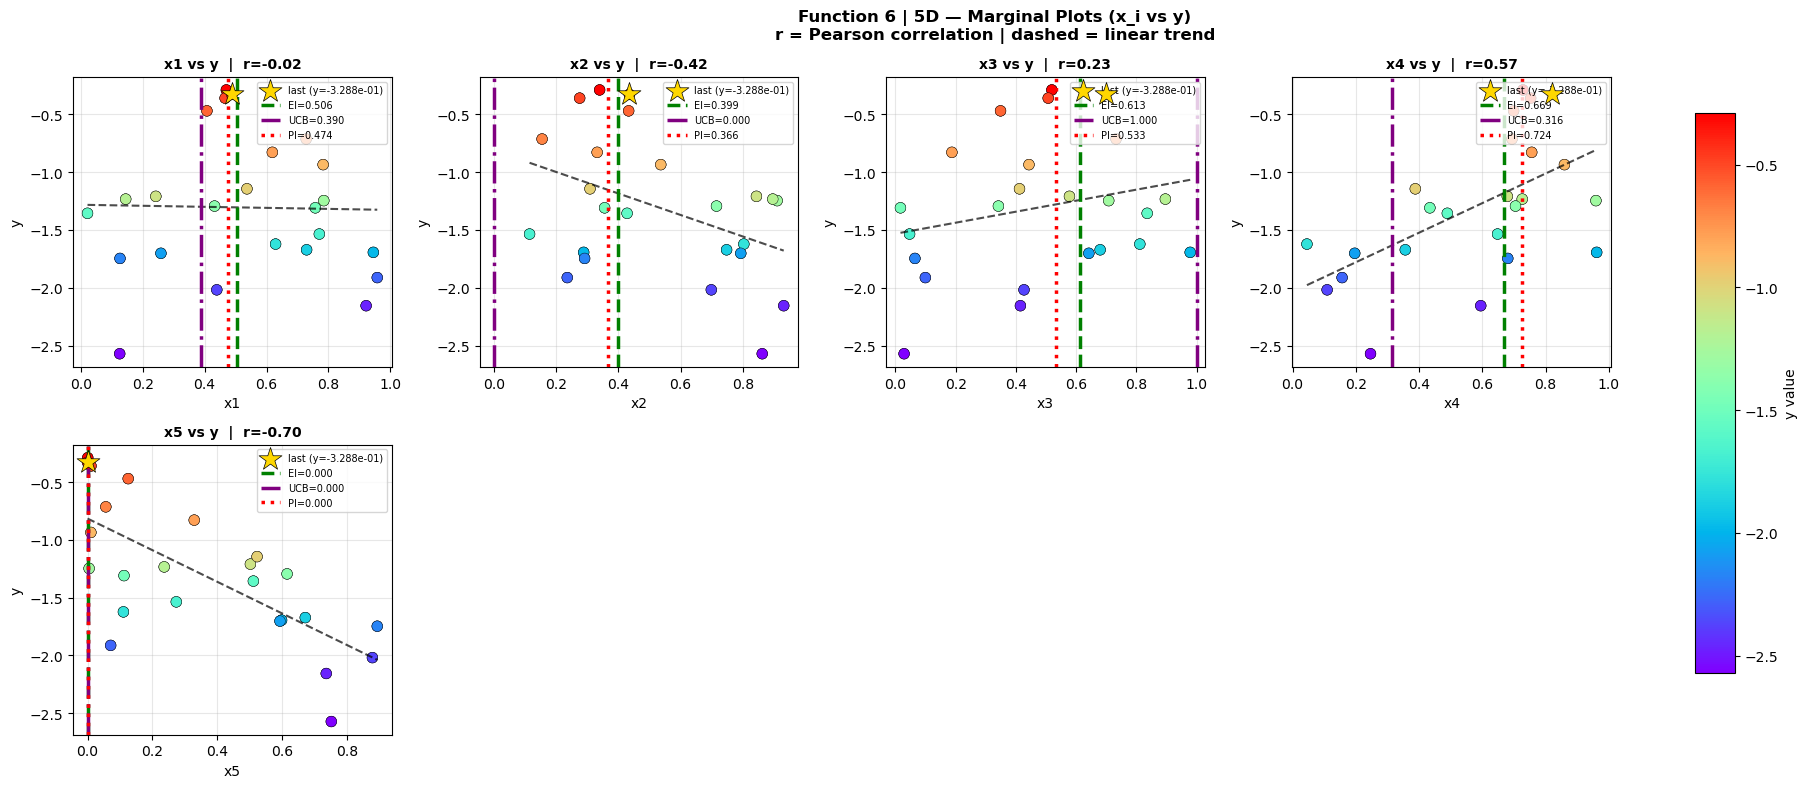

F7: 3 suggestion rows, cols: ['function', 'dimensions', 'acquisition', 'predicted_y', 'y_max_so_far', 'submission', 'x1_suggested', 'x2_suggested', 'x3_suggested', 'x4_suggested', 'x5_suggested', 'x6_suggested', 'x7_suggested', 'x8_suggested']


<positron-console-cell-11>:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


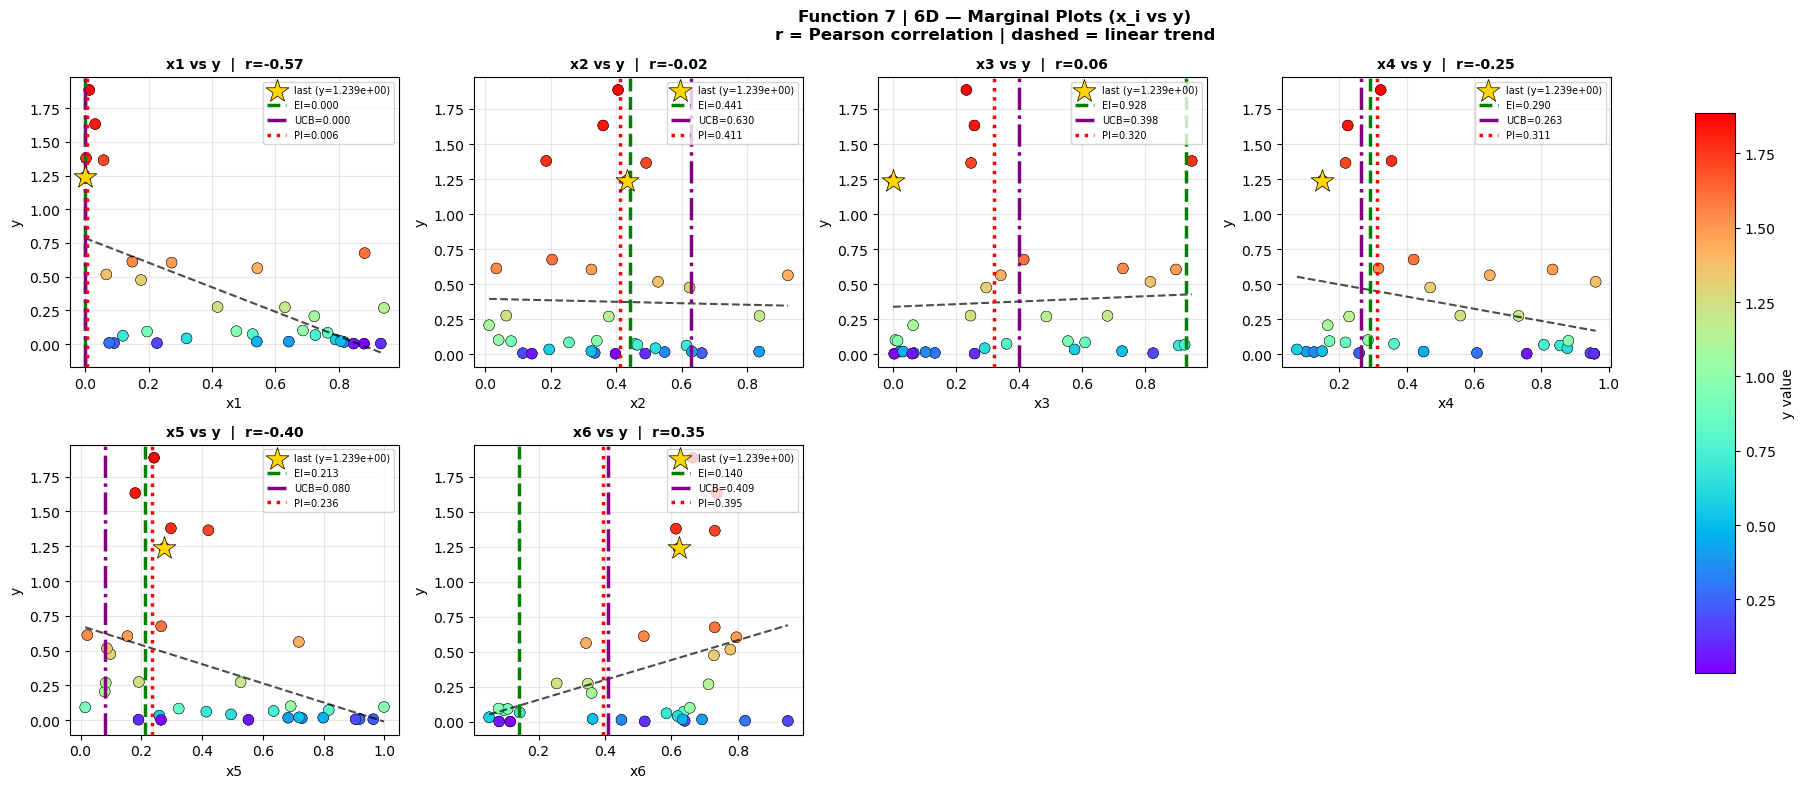

F8: 3 suggestion rows, cols: ['function', 'dimensions', 'acquisition', 'predicted_y', 'y_max_so_far', 'submission', 'x1_suggested', 'x2_suggested', 'x3_suggested', 'x4_suggested', 'x5_suggested', 'x6_suggested', 'x7_suggested', 'x8_suggested']


<positron-console-cell-11>:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


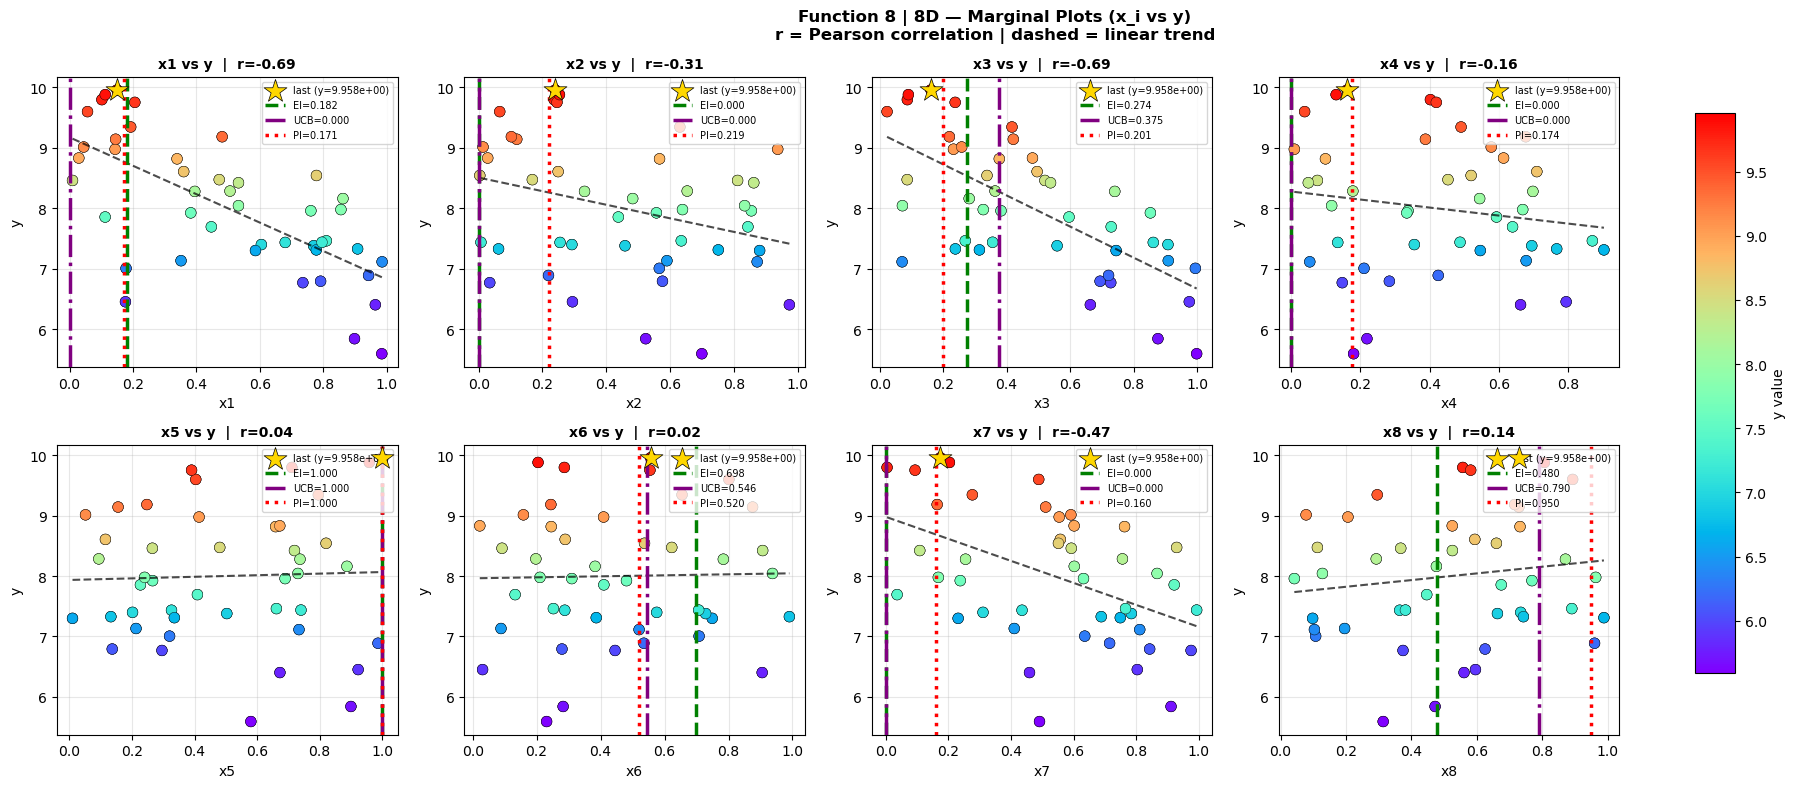

In [11]:
# PLOTTING MARGINAL PLOTS

def plot_function(fn_num, df_all=None):
    X        = all_X[fn_num - 1]
    y        = all_y[fn_num - 1]
    n_dim    = X.shape[1]
    dim_cols = X.columns.tolist()

    n_cols = min(4, n_dim)
    n_rows = int(np.ceil(n_dim / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(5 * n_cols, 4 * n_rows),
                             squeeze=False)

    y_rank = y.rank(pct=True)

    # ── Pre-fetch BO suggestions for this function
    acq_styles = {
        'EI':  dict(color='green',  linestyle='--', linewidth=2.5, zorder=5),
        'UCB': dict(color='purple', linestyle='-.',  linewidth=2.5, zorder=5),
        'PI':  dict(color='red',    linestyle=':',   linewidth=2.5, zorder=5),
    }
    fn_suggestions = None
    if df_all is not None:
        fn_suggestions = df_all[df_all['function'] == fn_num]
        print(f"F{fn_num}: {len(fn_suggestions)} suggestion rows, cols: {fn_suggestions.columns.tolist()}")

    for idx, col in enumerate(dim_cols):
        row, col_idx = divmod(idx, n_cols)
        ax = axes[row][col_idx]

        ax.scatter(X[col], y,
                   c=y_rank, cmap='rainbow',
                   s=60, edgecolors='k', linewidths=0.3, zorder=2)

        z = np.polyfit(X[col], y, 1)
        p = np.poly1d(z)
        x_line = np.linspace(X[col].min(), X[col].max(), 100)
        ax.plot(x_line, p(x_line), color='black', linewidth=1.5,
                linestyle='--', alpha=0.7, zorder=3)

        corr = X[col].corr(y)
        ax.set_title(f'{col} vs y  |  r={corr:.2f}', fontsize=10, fontweight='bold')
        ax.set_xlabel(col)
        ax.set_ylabel('y')
        ax.grid(True, alpha=0.3)
        ax.scatter(X[col], y,
                   c=y_rank, cmap='rainbow',
                   s=60, edgecolors='k', linewidths=0.3, zorder=2)

        # ── Last submitted point (star marker)
        ax.scatter(X[col].iloc[-1], y.iloc[-1],
                   marker='*', s=300, color='gold',
                   edgecolors='black', linewidths=0.5,
                   zorder=6, label=f'last (y={y.iloc[-1]:.3e})')
        ax.legend(fontsize=7, loc='upper right')

        # ── Draw vertical lines inline — no separate function needed
        if fn_suggestions is not None:
            suggested_col = f'{col}_suggested'
            if suggested_col in fn_suggestions.columns:
                for _, srow in fn_suggestions.iterrows():
                    x_val = srow[suggested_col]
                    acq   = srow['acquisition']
                    ax.axvline(x=x_val, **acq_styles.get(acq, {}),
                               label=f"{acq}={x_val:.3f}")
                ax.legend(fontsize=7, loc='upper right')

    for idx in range(n_dim, n_rows * n_cols):
        row, col_idx = divmod(idx, n_cols)
        axes[row][col_idx].set_visible(False)

    fig.subplots_adjust(right=0.82)
    cbar_ax = fig.add_axes([0.85, 0.15, 0.02, 0.7])
    sm = plt.cm.ScalarMappable(cmap='rainbow',
                                norm=plt.Normalize(vmin=y.min(), vmax=y.max()))
    sm.set_array([])
    fig.colorbar(sm, cax=cbar_ax, label='y value')

    plt.suptitle(f'Function {fn_num} | {n_dim}D — Marginal Plots (x_i vs y)\n'
                 f'r = Pearson correlation | dashed = linear trend',
                 fontweight='bold', fontsize=12)
    plt.tight_layout(rect=[0, 0, 0.82, 1])
    plt.show()

for fn in range(1, 9):
    plot_function(fn, df_all=df_all)

/home/omkarsjoshi/miniconda3/envs/ICL/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/omkarsjoshi/miniconda3/envs/ICL/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 1 of parameter length_scale is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/omkarsjoshi/miniconda3/envs/ICL/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter length_scale is close to the specified upper bound 10000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


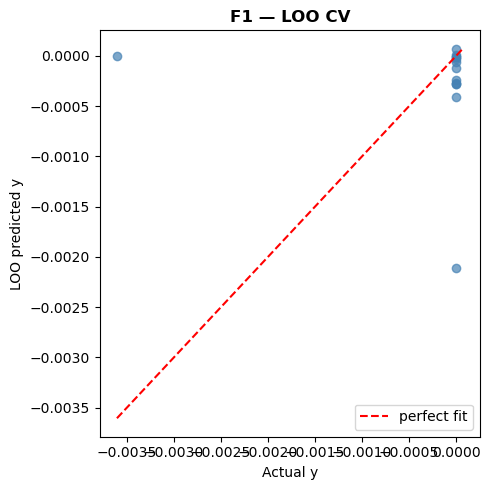

F1 LOO R²=-0.484, RMSE=0.0011


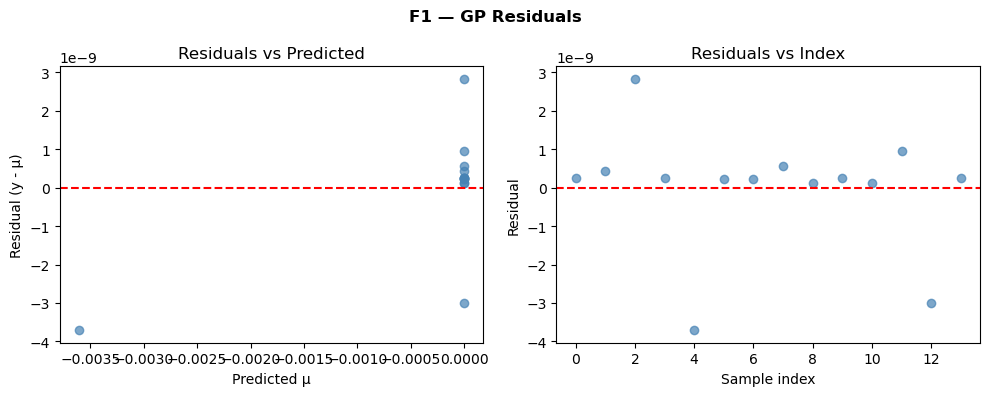

F1 calibration:
  Within 1σ: 100.0% (expect ~68%)
  Within 2σ: 100.0% (expect ~95%)
  ⚠ GP likely underconfident (too wide bands)


/home/omkarsjoshi/miniconda3/envs/ICL/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter length_scale is close to the specified upper bound 10000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


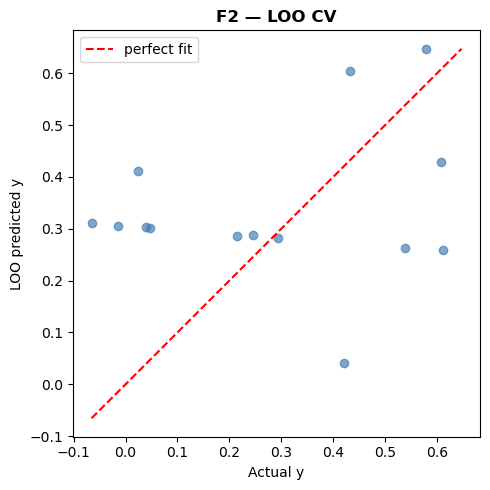

F2 LOO R²=-0.173, RMSE=0.2600


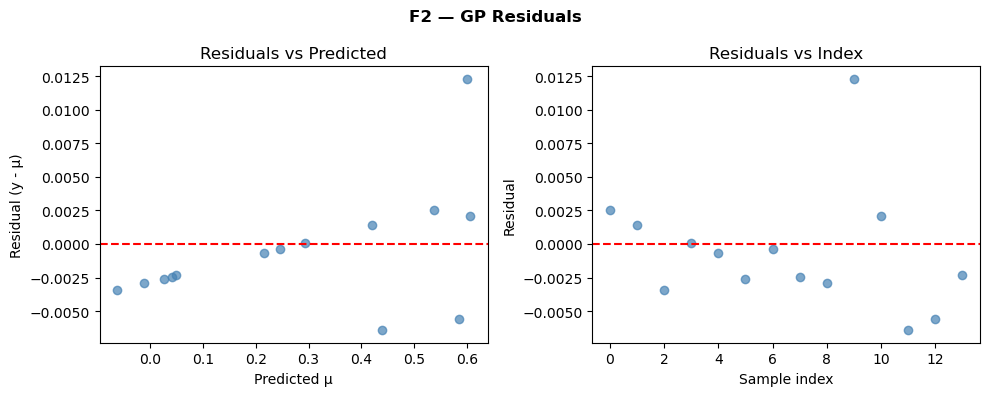

F2 calibration:
  Within 1σ: 100.0% (expect ~68%)
  Within 2σ: 100.0% (expect ~95%)
  ⚠ GP likely underconfident (too wide bands)


/home/omkarsjoshi/miniconda3/envs/ICL/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter length_scale is close to the specified upper bound 10000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/omkarsjoshi/miniconda3/envs/ICL/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified upper bound 10000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/omkarsjoshi/miniconda3/envs/ICL/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified upper bound 10000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/omkarsjoshi/mini

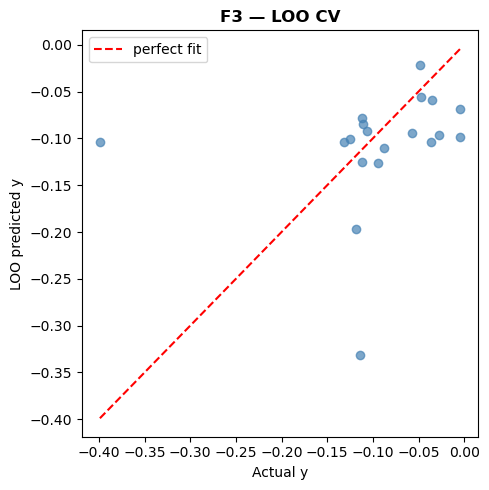

F3 LOO R²=-0.310, RMSE=0.0948


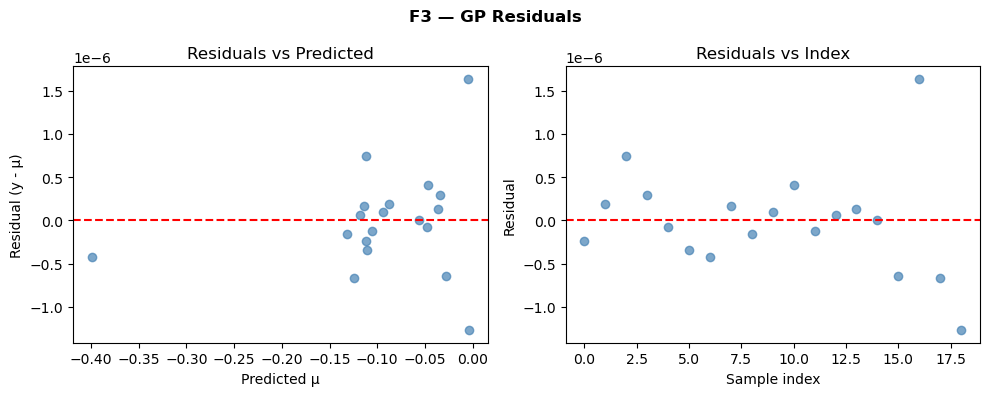

F3 calibration:
  Within 1σ: 100.0% (expect ~68%)
  Within 2σ: 100.0% (expect ~95%)
  ⚠ GP likely underconfident (too wide bands)


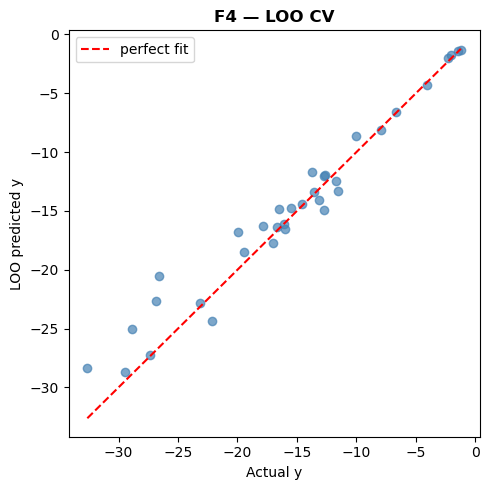

F4 LOO R²=0.945, RMSE=1.9374


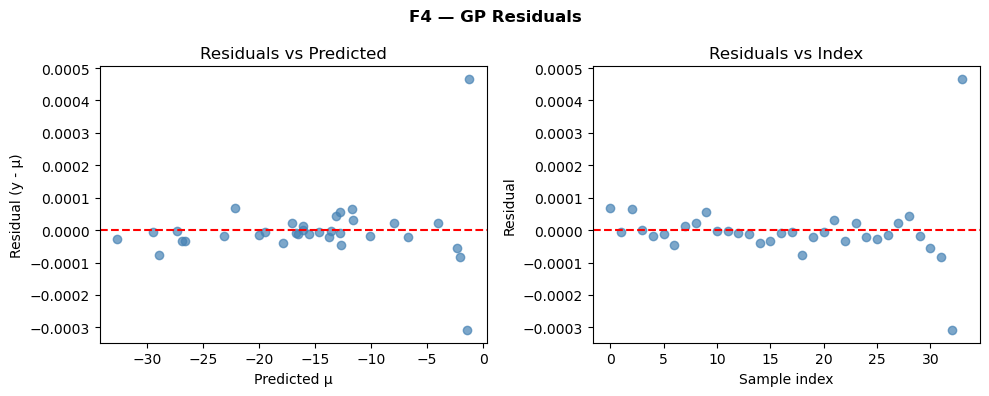

F4 calibration:
  Within 1σ: 100.0% (expect ~68%)
  Within 2σ: 100.0% (expect ~95%)
  ⚠ GP likely underconfident (too wide bands)


/home/omkarsjoshi/miniconda3/envs/ICL/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter length_scale is close to the specified upper bound 10000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/omkarsjoshi/miniconda3/envs/ICL/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter length_scale is close to the specified upper bound 10000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/omkarsjoshi/miniconda3/envs/ICL/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter length_scale is close to the specified upper bound 10000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


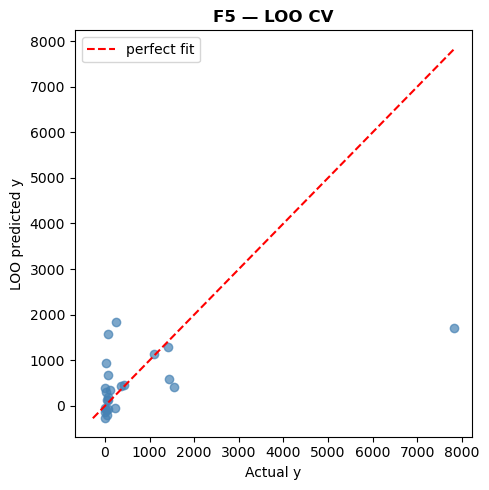

F5 LOO R²=0.230, RMSE=1383.7902


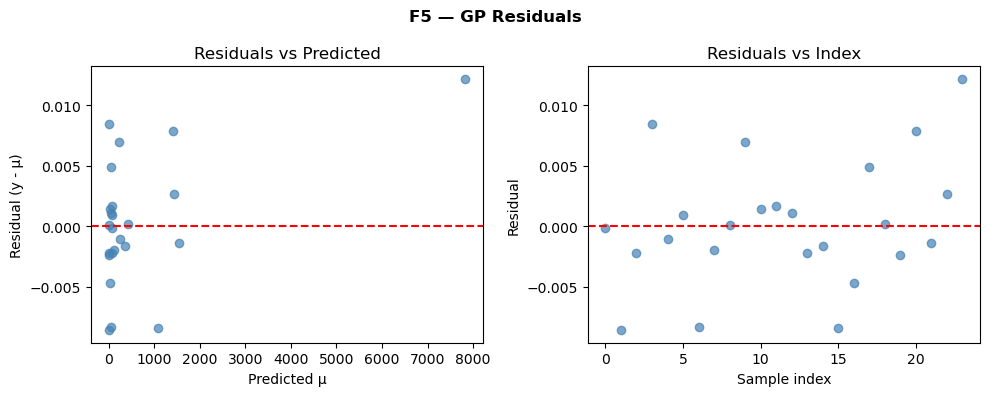

F5 calibration:
  Within 1σ: 100.0% (expect ~68%)
  Within 2σ: 100.0% (expect ~95%)
  ⚠ GP likely underconfident (too wide bands)


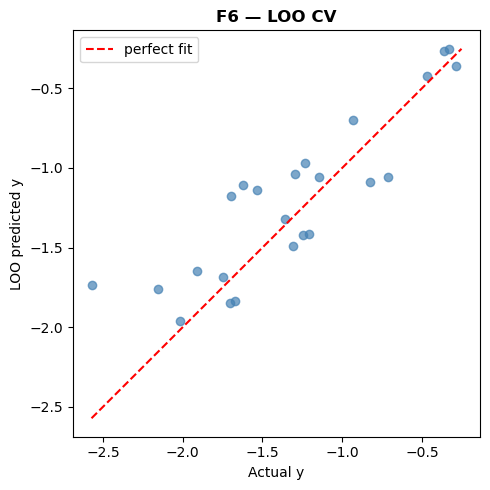

F6 LOO R²=0.738, RMSE=0.3017


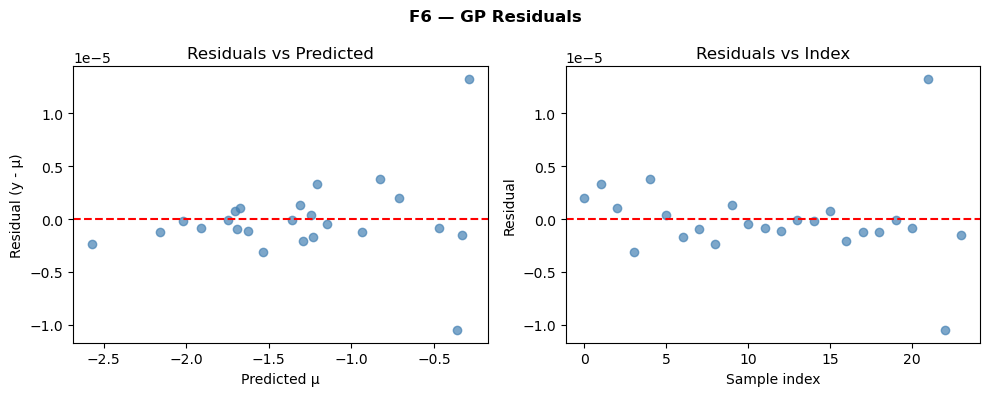

F6 calibration:
  Within 1σ: 100.0% (expect ~68%)
  Within 2σ: 100.0% (expect ~95%)
  ⚠ GP likely underconfident (too wide bands)


/home/omkarsjoshi/miniconda3/envs/ICL/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter length_scale is close to the specified upper bound 10000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/omkarsjoshi/miniconda3/envs/ICL/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 3 of parameter length_scale is close to the specified upper bound 10000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/omkarsjoshi/miniconda3/envs/ICL/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter length_scale is close to the specified upper bound 10000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/omkarsjoshi/mini

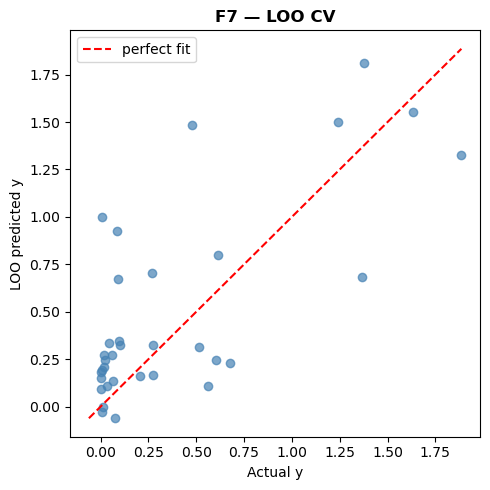

F7 LOO R²=0.402, RMSE=0.3997


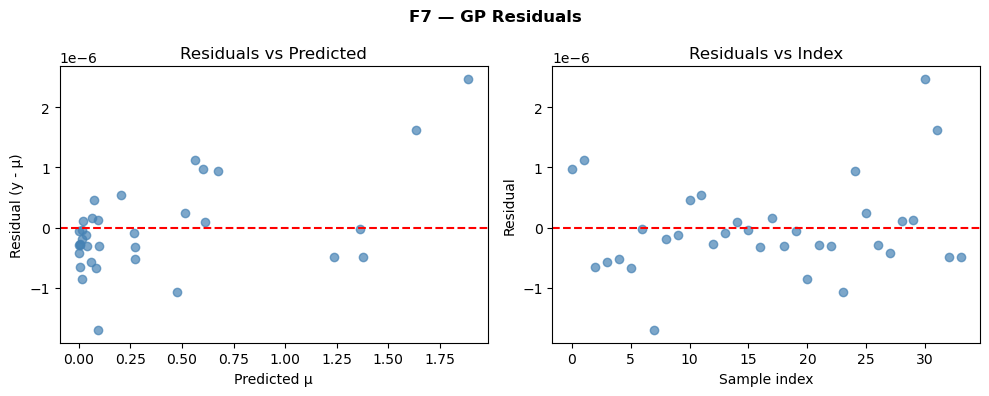

F7 calibration:
  Within 1σ: 100.0% (expect ~68%)
  Within 2σ: 100.0% (expect ~95%)
  ⚠ GP likely underconfident (too wide bands)


/home/omkarsjoshi/miniconda3/envs/ICL/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 5 of parameter length_scale is close to the specified upper bound 10000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/omkarsjoshi/miniconda3/envs/ICL/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 7 of parameter length_scale is close to the specified upper bound 10000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/omkarsjoshi/miniconda3/envs/ICL/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 5 of parameter length_scale is close to the specified upper bound 10000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/omkarsjoshi/mini

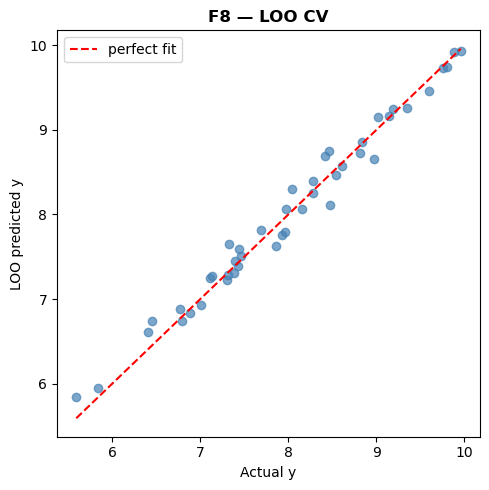

F8 LOO R²=0.978, RMSE=0.1582


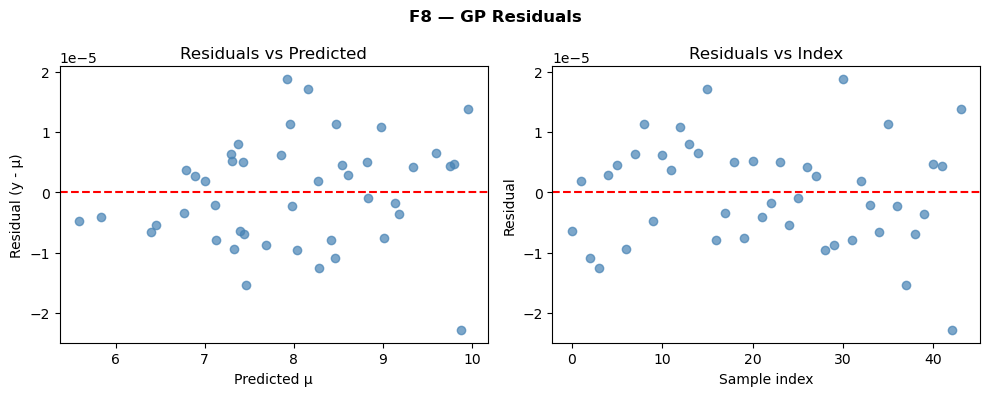

F8 calibration:
  Within 1σ: 100.0% (expect ~68%)
  Within 2σ: 100.0% (expect ~95%)
  ⚠ GP likely underconfident (too wide bands)


In [12]:
# GP PERFORMANCE (LOOCV, RESIDUALS, CALIBRATION/COVERAGE)

def loo_cv(fn_num, gp):
    X = all_X[fn_num - 1].values
    y = all_y[fn_num - 1].values
    n = len(y)
    preds = []
    
    for i in range(n):
        X_train = np.delete(X, i, axis=0)
        y_train = np.delete(y, i)
        X_test  = X[i].reshape(1, -1)
        gp_loo  = clone(gp).fit(X_train, y_train)
        preds.append(gp_loo.predict(X_test)[0])
    
    preds = np.array(preds)
    
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(y, preds, alpha=0.7, color='steelblue')
    lims = [min(y.min(), preds.min()), max(y.max(), preds.max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='perfect fit')
    ax.set_xlabel('Actual y')
    ax.set_ylabel('LOO predicted y')
    ax.set_title(f'F{fn_num} — LOO CV', fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.show()
    
    r2 = 1 - np.sum((y - preds)**2) / np.sum((y - y.mean())**2)
    rmse = np.sqrt(np.mean((y - preds)**2))
    print(f'F{fn_num} LOO R²={r2:.3f}, RMSE={rmse:.4f}')
    return r2, rmse

def plot_residuals(fn_num, gp):
    X = all_X[fn_num - 1].values
    y = all_y[fn_num - 1].values
    mu, sigma = gp.predict(X, return_std=True)
    residuals = y - mu
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    
    # residuals vs predicted
    axes[0].scatter(mu, residuals, alpha=0.7, color='steelblue')
    axes[0].axhline(0, color='red', linestyle='--')
    axes[0].set_xlabel('Predicted μ')
    axes[0].set_ylabel('Residual (y - μ)')
    axes[0].set_title('Residuals vs Predicted')
    
    # residuals vs index
    axes[1].scatter(range(len(y)), residuals, alpha=0.7, color='steelblue')
    axes[1].axhline(0, color='red', linestyle='--')
    axes[1].set_xlabel('Sample index')
    axes[1].set_ylabel('Residual')
    axes[1].set_title('Residuals vs Index')
    
    fig.suptitle(f'F{fn_num} — GP Residuals', fontweight='bold')
    plt.tight_layout()
    plt.show()

def calibration_check(fn_num, gp):
    X = all_X[fn_num - 1].values
    y = all_y[fn_num - 1].values
    mu, sigma = gp.predict(X, return_std=True)
    
    within_1sigma = np.mean(np.abs(y - mu) <= sigma)
    within_2sigma = np.mean(np.abs(y - mu) <= 2 * sigma)
    
    print(f'F{fn_num} calibration:')
    print(f'  Within 1σ: {within_1sigma:.1%} (expect ~68%)')
    print(f'  Within 2σ: {within_2sigma:.1%} (expect ~95%)')
    
    if within_2sigma < 0.80:
        print('  ⚠ GP likely overconfident')
    elif within_2sigma > 0.99:
        print('  ⚠ GP likely underconfident (too wide bands)')
    else:
        print('  ✓ reasonably calibrated')

from sklearn.base import clone

for fn in range(1, 9):
    gp = gps[fn]
    loo_cv(fn, gp)
    plot_residuals(fn, gp)
    calibration_check(fn, gp)

In [13]:
# RANKING DIMENSIONS

def rank_dimensions(fn_num, top_n=4):
    X = all_X[fn_num - 1]
    y = all_y[fn_num - 1]
    
    rf = RandomForestRegressor(n_estimators=200, random_state=42)
    rf.fit(X, y)
    importances = rf.feature_importances_
    order = np.argsort(importances)[::-1]
    coverage = importances[order[:top_n]].sum()
    
    print(f"\nF{fn_num} — dimension importance ranking:")
    for rank, i in enumerate(order):
        marker = " ◄ plot" if rank < top_n else ""
        print(f"  {X.columns[i]}: {importances[i]:.4f}{marker}")
    print(f"  Top-{top_n} coverage: {coverage:.1%}")
    
    return X.columns[order[:top_n]].tolist(), X.columns[order].tolist(), rf, order

top_dims = {}
ranked_dims = {}

for fn_num in range(1, 9):
    n_dim = all_X[fn_num - 1].shape[1]
    top_n = min(4, n_dim)
    top_dims[fn_num], ranked_dims[fn_num], _, _ = rank_dimensions(fn_num, top_n=top_n)

print("\n--- Summary ---")
for fn_num in range(1, 9):
    print(f"F{fn_num}: top dims = {top_dims[fn_num]}")
    print(f"      all dims (desc) = {ranked_dims[fn_num]}")


F1 — dimension importance ranking:
  x2: 0.5720 ◄ plot
  x1: 0.4280 ◄ plot
  Top-2 coverage: 100.0%

F2 — dimension importance ranking:
  x2: 0.5726 ◄ plot
  x1: 0.4274 ◄ plot
  Top-2 coverage: 100.0%

F3 — dimension importance ranking:
  x3: 0.8149 ◄ plot
  x1: 0.1167 ◄ plot
  x2: 0.0684 ◄ plot
  Top-3 coverage: 100.0%

F4 — dimension importance ranking:
  x1: 0.3194 ◄ plot
  x2: 0.3069 ◄ plot
  x4: 0.2375 ◄ plot
  x3: 0.1362 ◄ plot
  Top-4 coverage: 100.0%

F5 — dimension importance ranking:
  x3: 0.5000 ◄ plot
  x2: 0.2322 ◄ plot
  x1: 0.2072 ◄ plot
  x4: 0.0606 ◄ plot
  Top-4 coverage: 100.0%

F6 — dimension importance ranking:
  x5: 0.4303 ◄ plot
  x4: 0.3279 ◄ plot
  x2: 0.1094 ◄ plot
  x1: 0.0841 ◄ plot
  x3: 0.0481
  Top-4 coverage: 95.2%

F7 — dimension importance ranking:
  x1: 0.8108 ◄ plot
  x5: 0.0623 ◄ plot
  x6: 0.0449 ◄ plot
  x2: 0.0393 ◄ plot
  x3: 0.0290
  x4: 0.0137
  Top-4 coverage: 95.7%

F8 — dimension importance ranking:
  x1: 0.3961 ◄ plot
  x3: 0.3691 ◄ plot


In [ ]:
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
import numpy as np

def nn_candidate(fn_num, n_restarts=10, steps=500, lr=0.01):
    X = all_X[fn_num - 1].values
    y = all_y[fn_num - 1].values.reshape(-1, 1)
    n_dim = X.shape[1]

    x_sc = StandardScaler()
    y_sc = StandardScaler()
    Xs = x_sc.fit_transform(X)
    ys = y_sc.fit_transform(y).ravel()

    Xt = torch.tensor(Xs, dtype=torch.float32)
    yt = torch.tensor(ys, dtype=torch.float32).unsqueeze(1)

    hidden = max(16, n_dim * 4)
    model = nn.Sequential(
        nn.Linear(n_dim, hidden), nn.Tanh(),
        nn.Linear(hidden, hidden // 2), nn.Tanh(),
        nn.Linear(hidden // 2, 1)
    )
    opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-2)
    loss_fn = nn.MSELoss()

    for _ in range(1000):
        model.train()
        opt.zero_grad()
        loss_fn(model(Xt), yt).backward()
        opt.step()

    # --- gradient ascent from multiple random restarts ---
    # scale bounds: X is in [0,1]^d, so compute scaled bounds
    lo = torch.tensor(x_sc.transform(np.zeros((1, n_dim))), dtype=torch.float32)
    hi = torch.tensor(x_sc.transform(np.ones((1, n_dim))),  dtype=torch.float32)

    best_val, best_x = -np.inf, None
    model.eval()
    for _ in range(n_restarts):
        # random start in scaled [0,1]^d
        x0_raw = np.random.rand(1, n_dim)
        x0 = torch.tensor(x_sc.transform(x0_raw), dtype=torch.float32, requires_grad=True)
        asc = torch.optim.Adam([x0], lr=lr)

        for _ in range(steps):
            asc.zero_grad()
            (-model(x0)).backward()          # ascent = negate loss
            asc.step()
            with torch.no_grad():
                x0.clamp_(lo, hi)            # stay in bounds

        val = model(x0).item()
        if val > best_val:
            best_val = val
            # inverse-transform back to [0,1]^d
            best_x = x_sc.inverse_transform(x0.detach().numpy()).clip(0, 1)

    print(f"F{fn_num}: NN candidate = {best_x.ravel()}")
    return best_x.ravel()

nn_candidates = {fn: nn_candidate(fn) for fn in range(1, 9)}

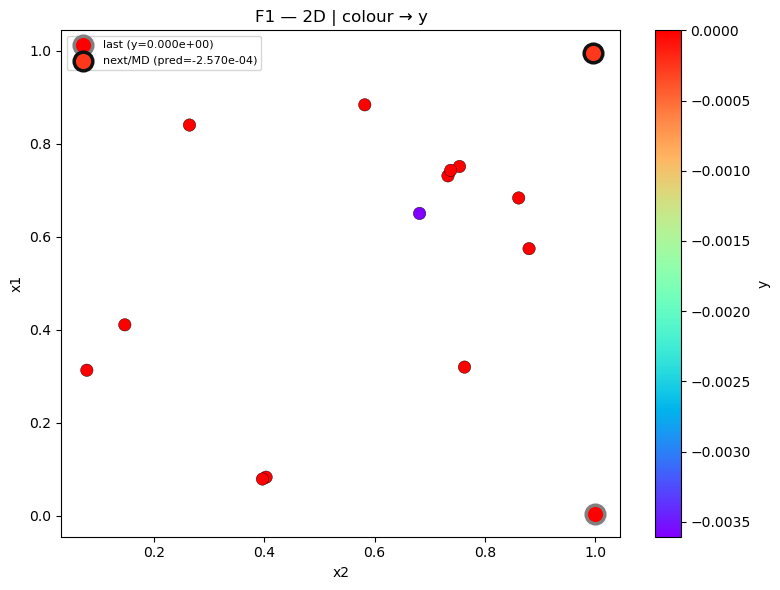

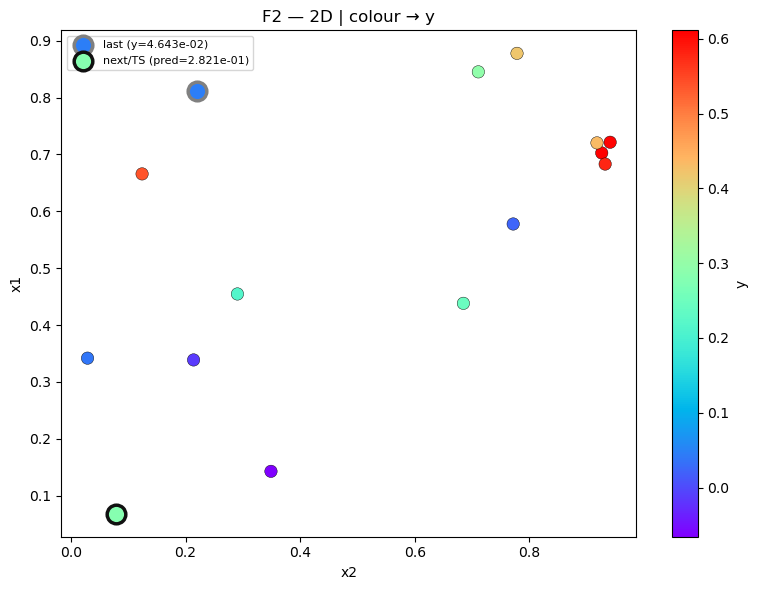

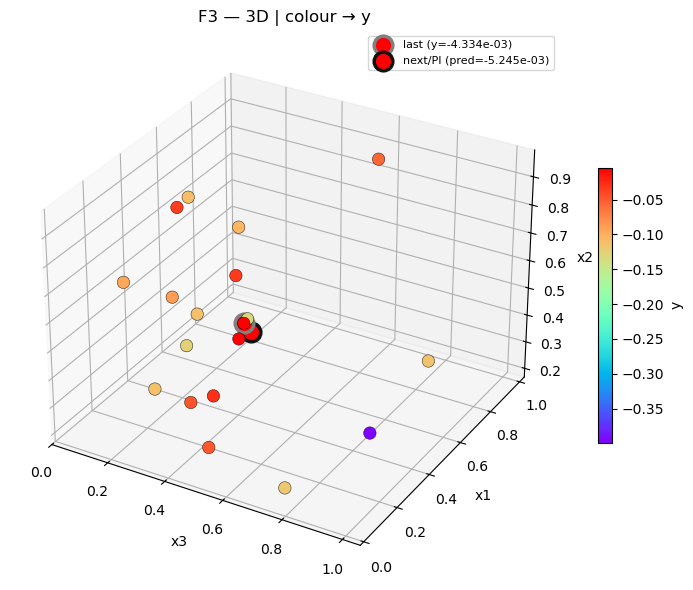

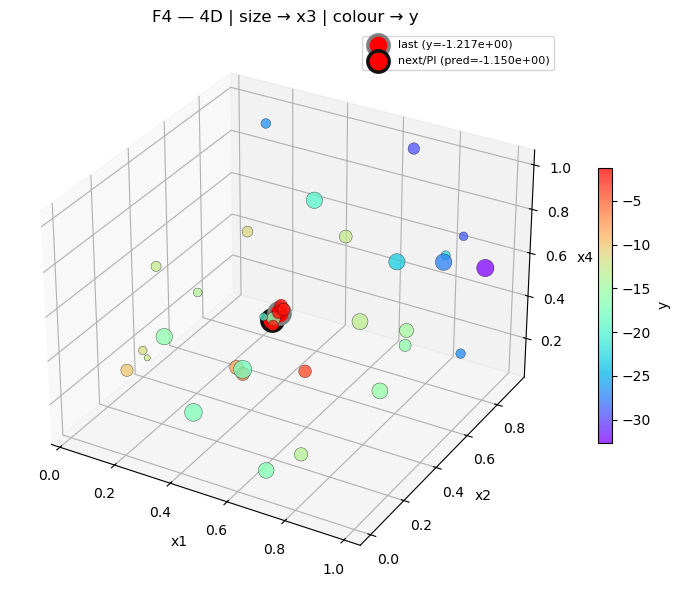

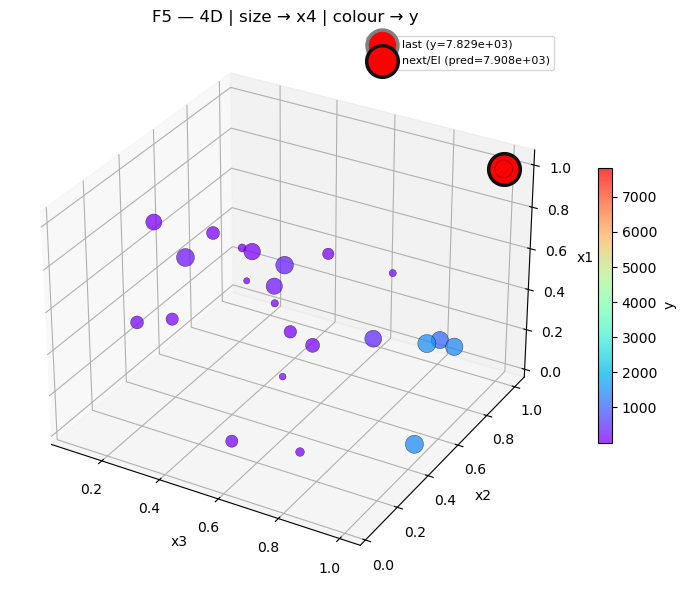

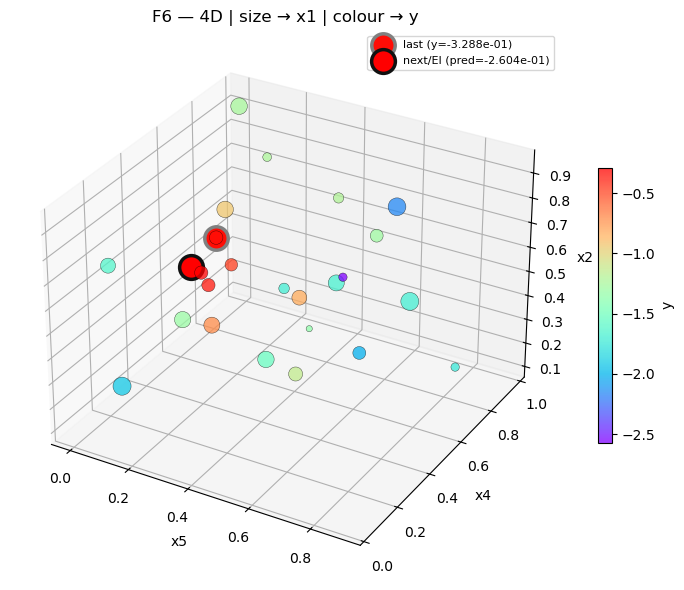

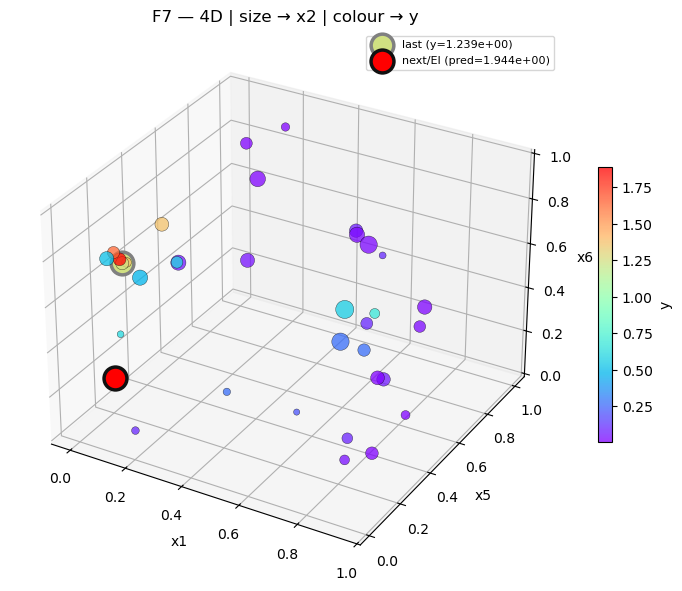

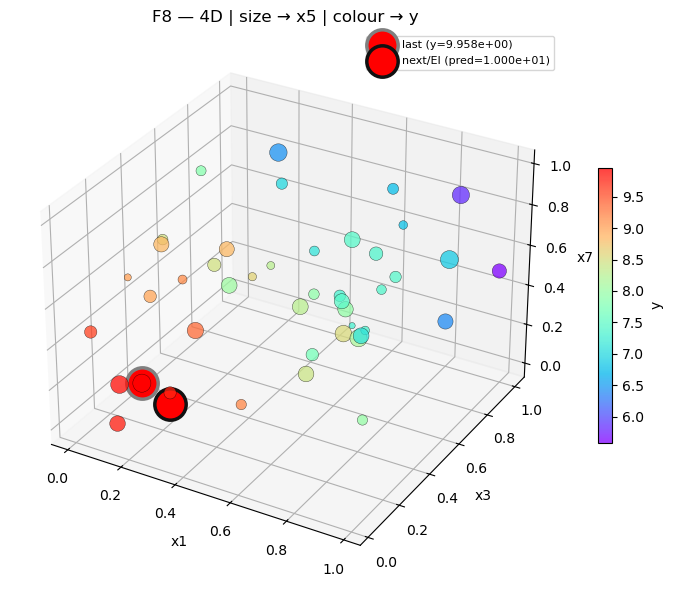

In [ ]:
#4D SCATTERPL

def plot_smart(fn_num, top_dims_dict=top_dims, best_df=df_best):
    X = all_X[fn_num - 1]
    y = all_y[fn_num - 1]
    dims = top_dims_dict[fn_num]
    n_dim = X.shape[1]
    plot_dims = dims if n_dim <= 4 else dims[:4]
    n_plot = len(plot_dims)

    # ── colour setup first so everything can use it
    y_arr = y.values if hasattr(y, 'values') else y
    norm = plt.Normalize(y_arr.min(), y_arr.max())
    cmap = plt.cm.rainbow
    last_color = cmap(norm(y_arr[-1]))

    # ── Pull best suggestion from df_best
    best_row = df_best.loc[fn_num]
    all_dims = all_X[fn_num - 1].columns.tolist()
    coord_map = dict(zip(all_dims, best_row['x_next']))
    sugg_coords = {col: coord_map[col] for col in plot_dims}
    sugg_label = f"next/{best_row['acquisition']} (pred={best_row['predicted_y']:.3e})"
    sugg_color = cmap(norm(best_row['predicted_y']))

    fig = plt.figure(figsize=(8, 6))
    y_arr = y.values if hasattr(y, 'values') else y
    norm = plt.Normalize(y_arr.min(), y_arr.max())
    cmap = plt.cm.rainbow
    last_color = cmap(norm(y_arr[-1]))
    GOLD = '#FFD700'

# ── 2D
    if n_plot == 2:
        d1, d2 = plot_dims
        ax = fig.add_subplot(111)
        sc = ax.scatter(X[d1], X[d2], c=y_arr, cmap=cmap, norm=norm,
                        s=80, alpha=1.0, edgecolors='k', linewidths=0.3)
        # last point — bold grey border
        ax.scatter(X[d1].iloc[-1], X[d2].iloc[-1],
                   marker='o', s=180, color=last_color,
                   edgecolors='grey', linewidths=2.5,
                   zorder=5, label=f'last (y={y_arr[-1]:.3e})')
        # suggested point — bold dark border, colour = predicted_y
        ax.scatter(sugg_coords[d1], sugg_coords[d2],
                   marker='o', s=180, color=sugg_color,
                   edgecolors='#111111', linewidths=2.5,
                   zorder=6, label=sugg_label)
        ax.set_xlabel(d1); ax.set_ylabel(d2)
        ax.legend(fontsize=8)
        fig.colorbar(sc, ax=ax, label='y')
        ax.set_title(f'F{fn_num} — 2D | colour → y')

    # ── 3D no size
    elif n_plot == 3:
        d1, d2, d3 = plot_dims
        ax = fig.add_subplot(111, projection='3d')
        sc = ax.scatter(X[d1], X[d2], X[d3], c=y_arr, cmap=cmap, norm=norm,
                        s=80, alpha=1.0, edgecolors='k', linewidths=0.3)
        # last point — bold grey border
        ax.scatter(X[d1].iloc[-1], X[d2].iloc[-1], X[d3].iloc[-1],
                   marker='o', s=180, color=last_color,
                   edgecolors='grey', linewidths=2.5,
                   zorder=5, label=f'last (y={y_arr[-1]:.3e})')
        # suggested point — bold dark border, colour = predicted_y
        ax.scatter(sugg_coords[d1], sugg_coords[d2], sugg_coords[d3],
                   marker='o', s=180, color=sugg_color,
                   edgecolors='#111111', linewidths=2.5,
                   zorder=6, label=sugg_label)
        ax.set_xlabel(d1); ax.set_ylabel(d2); ax.set_zlabel(d3)
        ax.legend(fontsize=8)
        fig.colorbar(sc, ax=ax, label='y', shrink=0.5)
        ax.set_title(f'F{fn_num} — 3D | colour → y')

    # ── 4D with size
# ── 4D with size
# ── 4D with size
    elif n_plot >= 4:
        d1, d2, d3, d4 = plot_dims[:4]
        x4_vals = X[d4].values
        x4_norm = (x4_vals - x4_vals.min()) / (x4_vals.max() - x4_vals.min() + 1e-12)
        sizes = 20 + x4_norm * 150

        last_x4_norm = (X[d4].iloc[-1] - x4_vals.min()) / (x4_vals.max() - x4_vals.min() + 1e-12)
        last_size = 20 + last_x4_norm * 150

        sugg_x4_norm = (sugg_coords[d4] - x4_vals.min()) / (x4_vals.max() - x4_vals.min() + 1e-12)
        sugg_size = 20 + sugg_x4_norm * 150

        # colour of suggested point based on predicted_y mapped onto same colormap/norm
        sugg_color = cmap(norm(best_row['predicted_y']))

        ax = fig.add_subplot(111, projection='3d')
        sc = ax.scatter(X[d1], X[d2], X[d3], c=y_arr, cmap=cmap, norm=norm,
                        s=sizes, alpha=0.75, edgecolors='k', linewidths=0.3)
        # last point — bold grey border
        ax.scatter(X[d1].iloc[-1], X[d2].iloc[-1], X[d3].iloc[-1],
                marker='o', s=last_size * 3, color=last_color,
                edgecolors='grey', linewidths=2.5,
                zorder=5, label=f'last (y={y_arr[-1]:.3e})')
        # suggested point — bold dark border, colour = predicted_y on same scale
        ax.scatter(sugg_coords[d1], sugg_coords[d2], sugg_coords[d3],
                marker='o', s=sugg_size * 3, color=sugg_color,
                edgecolors='#111111', linewidths=2.5,
                zorder=6, label=sugg_label)
        ax.set_xlabel(d1); ax.set_ylabel(d2); ax.set_zlabel(d3)
        ax.legend(fontsize=8)
        fig.colorbar(sc, ax=ax, label='y', shrink=0.5)
        ax.set_title(f'F{fn_num} — 4D | size → {d4} | colour → y')

    plt.tight_layout()
    plt.show()

for fn_num in range(1, 9):
    plot_smart(fn_num)

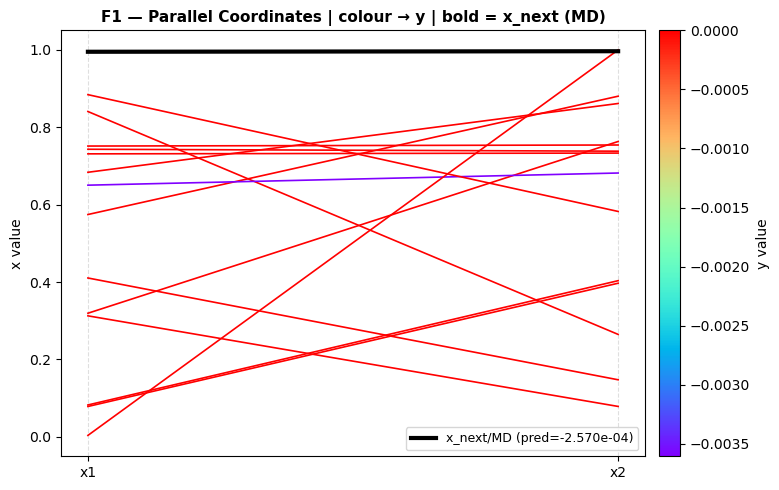

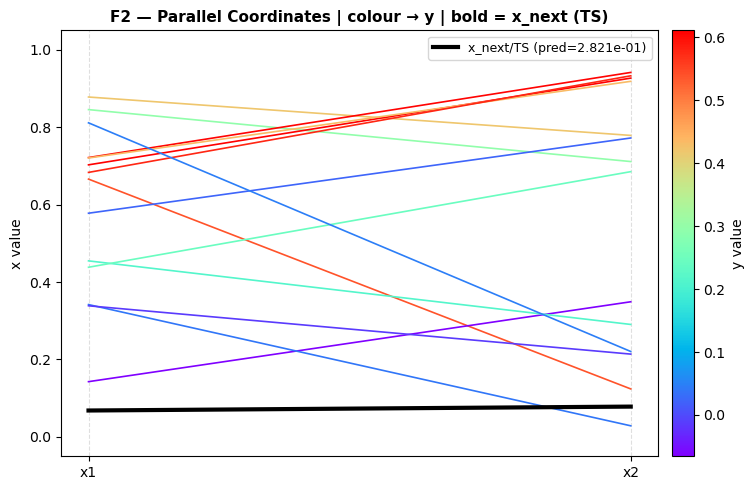

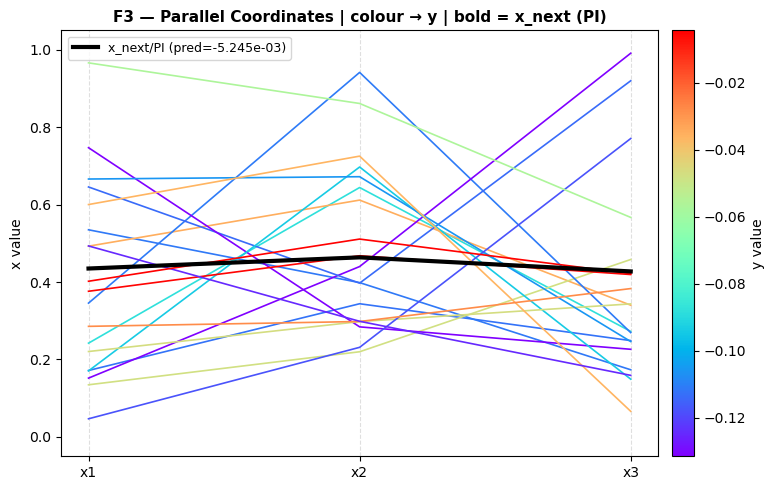

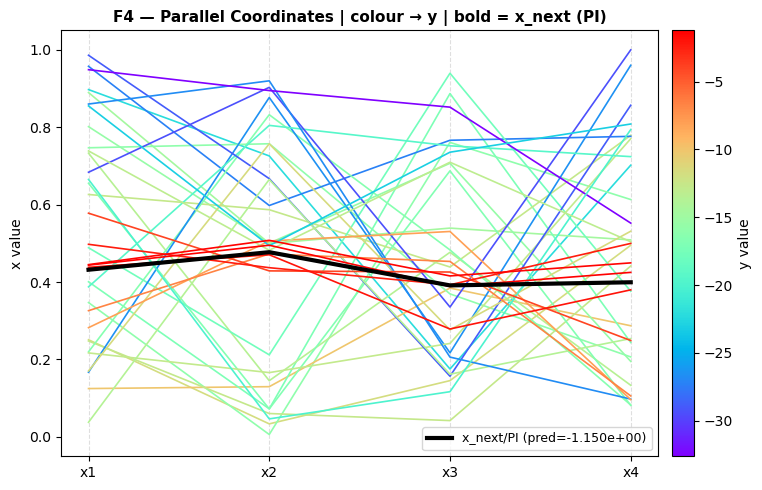

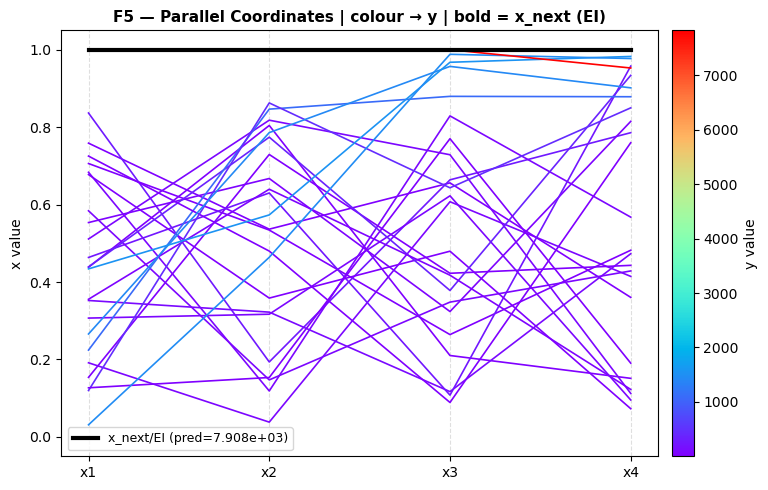

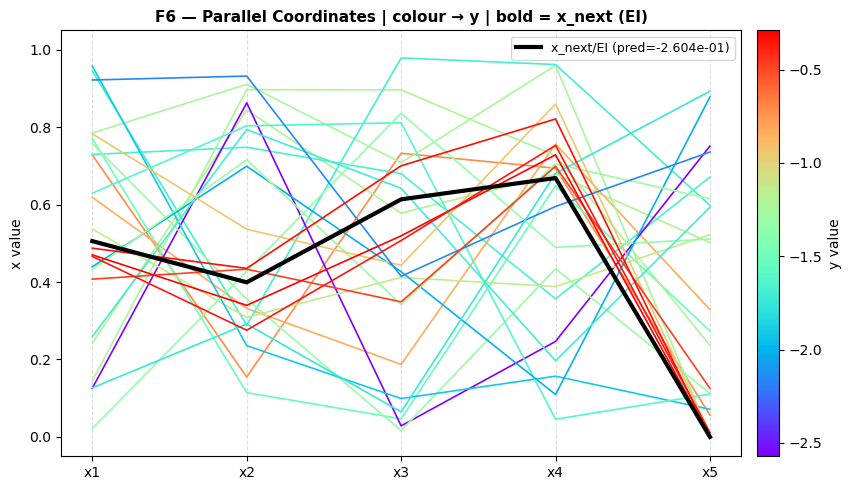

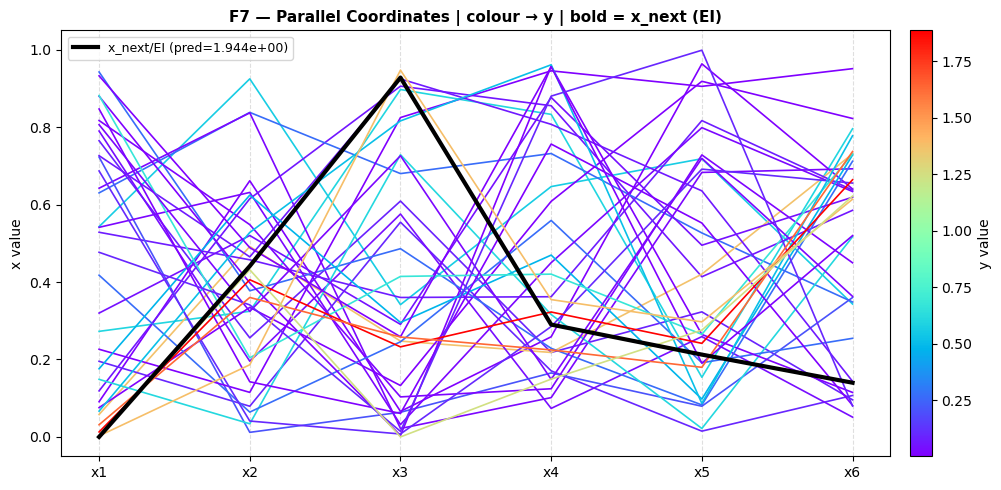

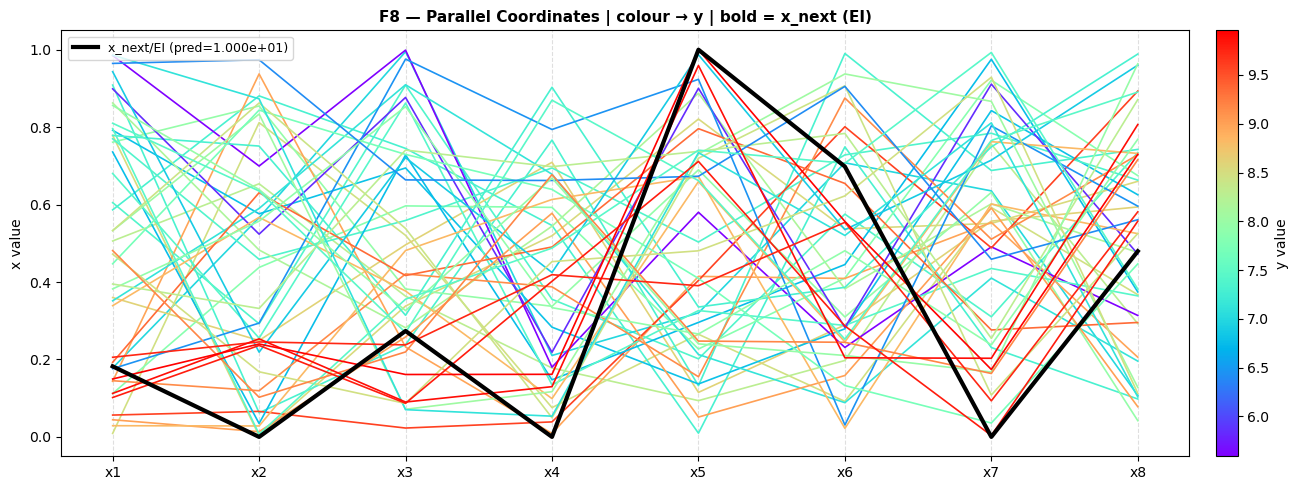

In [ ]:
# X_NEXT ON PARALLEL COORDINATE PLOT

import matplotlib.colors as mcolors
import matplotlib.cm as cm

def plot_parallel_coords(fn_num, df_best=df_best, clip_bottom=False):
    X     = all_X[fn_num - 1]
    y     = all_y[fn_num - 1]
    y_arr = y.values if hasattr(y, 'values') else y
    dims  = X.columns.tolist()
    n_dim = len(dims)

    if clip_bottom and len(y_arr) > 1:
        drop_idx   = np.argmin(y_arr)
        y_for_norm = np.delete(y_arr, drop_idx)
    else:
        y_for_norm = y_arr

    norm = mcolors.Normalize(vmin=y_for_norm.min(), vmax=y_for_norm.max())
    cmap = cm.rainbow

    best_row  = df_best.iloc[fn_num - 1]
    x_next    = np.array([float(v) for v in best_row['submission'].split('-')])
    acq_label = best_row['acquisition']
    pred_y    = best_row['predicted_y']

    fig, ax = plt.subplots(figsize=(max(8, n_dim * 1.8), 5))
    x_positions = np.arange(n_dim)

    for i in range(len(X)):
        vals  = X.iloc[i].values
        color = cmap(norm(np.clip(y_arr[i], y_for_norm.min(), y_for_norm.max())))
        ax.plot(x_positions, vals, color=color, linewidth=1.2, alpha=1.0)

    ax.plot(x_positions, x_next, color='black', linewidth=3.0,
            zorder=5, label=f'x_next/{acq_label} (pred={pred_y:.3e})')

    ax.set_xticks(x_positions)
    ax.set_xticklabels(dims, fontsize=10)
    ax.set_ylabel('x value', fontsize=10)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(axis='x', linestyle='--', alpha=0.4)
    ax.legend(fontsize=9)

    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, ax=ax, label='y value', pad=0.02)

    ax.set_title(f'F{fn_num} — Parallel Coordinates | colour → y | bold = x_next ({acq_label})',
                 fontweight='bold', fontsize=11)
    plt.tight_layout()
    plt.show()

for fn_num in range(1, 9):
    #if fn_num == 1:
     #   print('F1 skipped — near-flat function')
      #  continue
    plot_parallel_coords(fn_num, clip_bottom=(fn_num == 3))

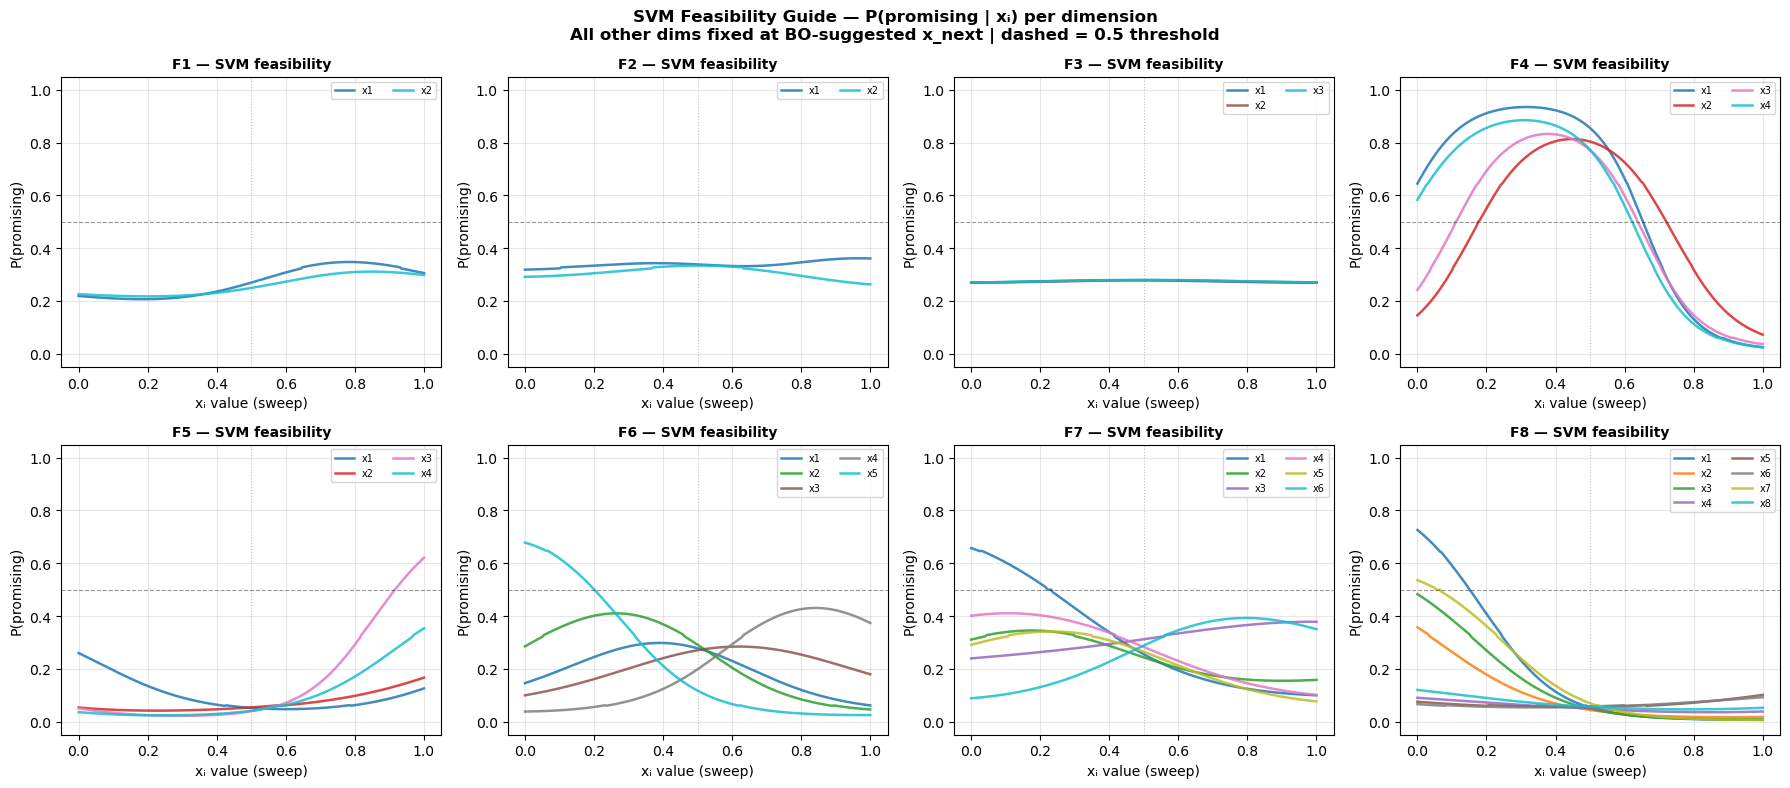

In [ ]:
# ── SVM FEASIBILITY OVERLAY — "promising region" confidence per function ──────
#
# For each function: a 1D sweep of P_SVM(promising | x) for each dimension,
# with all other dims held at the BO-suggested x_next.
# This mirrors the structure of plot_gp_slices so comparisons are intuitive.

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

t_sweep = np.linspace(1e-6, 0.999999, 200)

for fn_num in range(1, 9):
    ax = axes[fn_num - 1]
    svm = guide_svms.get(fn_num)

    if svm is None:
        ax.text(0.5, 0.5, 'SVM\nnot available', ha='center', va='center',
                transform=ax.transAxes, fontsize=10, color='grey')
        ax.set_title(f'F{fn_num}', fontweight='bold')
        continue

    X_raw  = all_X[fn_num - 1].values
    n_dim  = X_raw.shape[1]
    dim_cols = all_X[fn_num - 1].columns.tolist()
    scaler = svm._guide_scaler

    # Reference point: BO-suggested x_next for this function
    x_ref = np.mean(all_X[fn_num - 1].values, axis=0)

    colors_dim = plt.cm.tab10(np.linspace(0, 1, n_dim))

    for i, col in enumerate(dim_cols):
        X_sweep = np.tile(x_ref, (200, 1))
        X_sweep[:, i] = t_sweep
        X_sweep_s = scaler.transform(X_sweep)
        p_promising = svm.predict_proba(X_sweep_s)[:, 1]
        ax.plot(t_sweep, p_promising, color=colors_dim[i],
                linewidth=1.8, label=col, alpha=0.85)

    # Mark the suggested point
    ax.axvline(0.5, color='grey', linestyle=':', linewidth=0.8, alpha=0.5)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel('xᵢ value (sweep)')
    ax.set_ylabel('P(promising)')
    ax.set_title(f'F{fn_num} — SVM feasibility', fontweight='bold', fontsize=10)
    ax.legend(fontsize=7, ncol=2)
    ax.grid(True, alpha=0.3)
    ax.axhline(0.5, color='black', linestyle='--', linewidth=0.8, alpha=0.4)

fig.suptitle(
    'SVM Feasibility Guide — P(promising | xᵢ) per dimension\n'
    'All other dims fixed at BO-suggested x_next | dashed = 0.5 threshold',
    fontweight='bold', fontsize=12
)
plt.tight_layout()
plt.show()

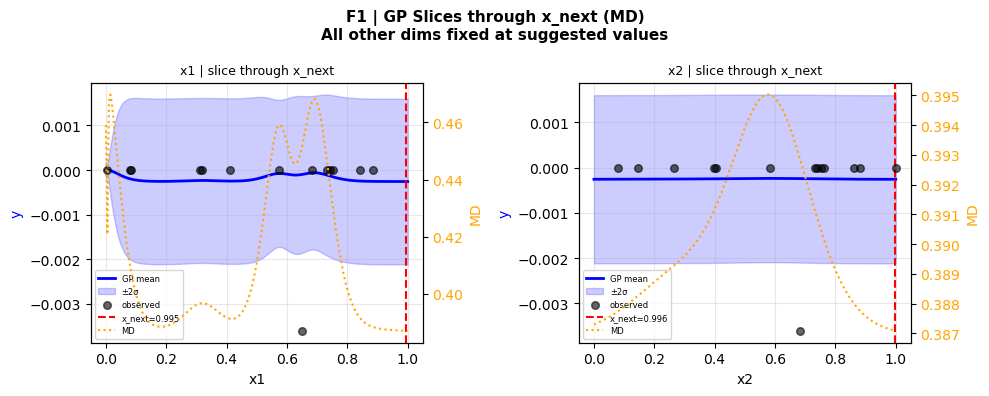

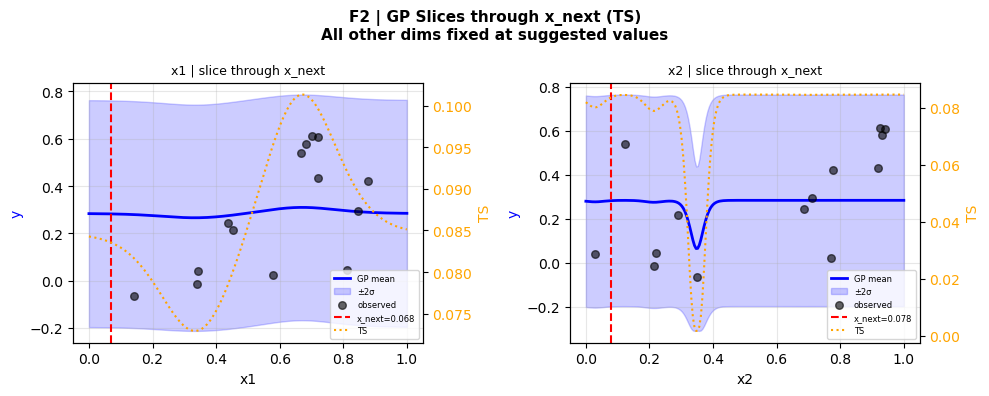

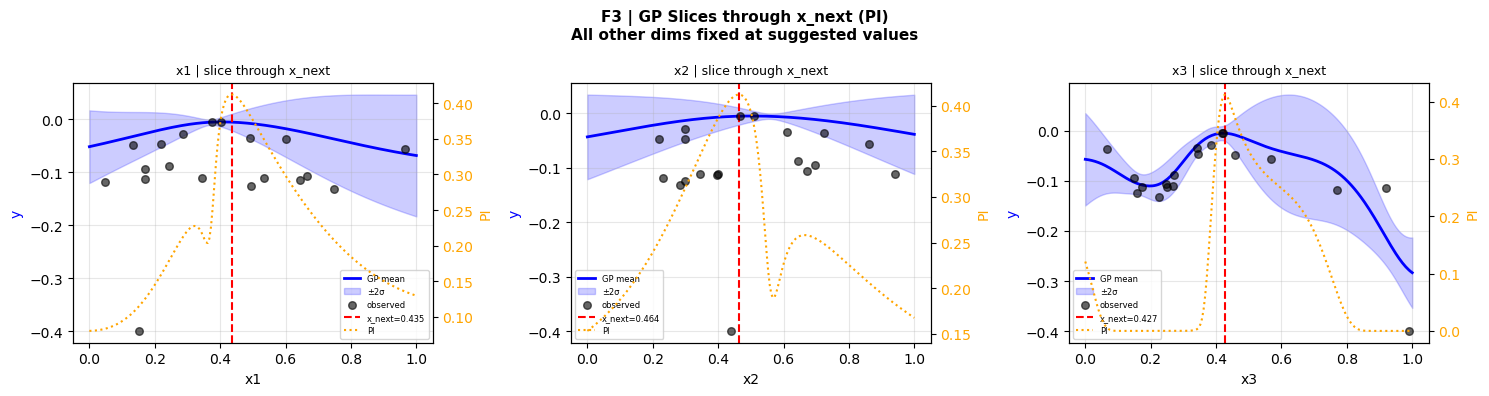

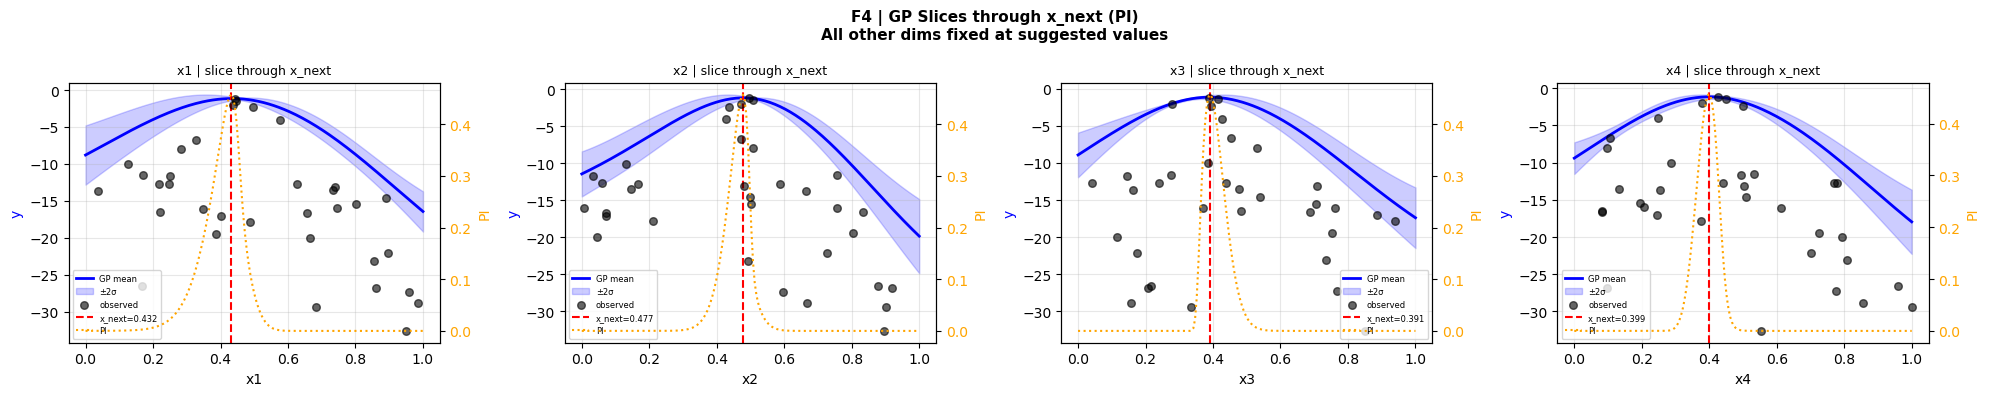

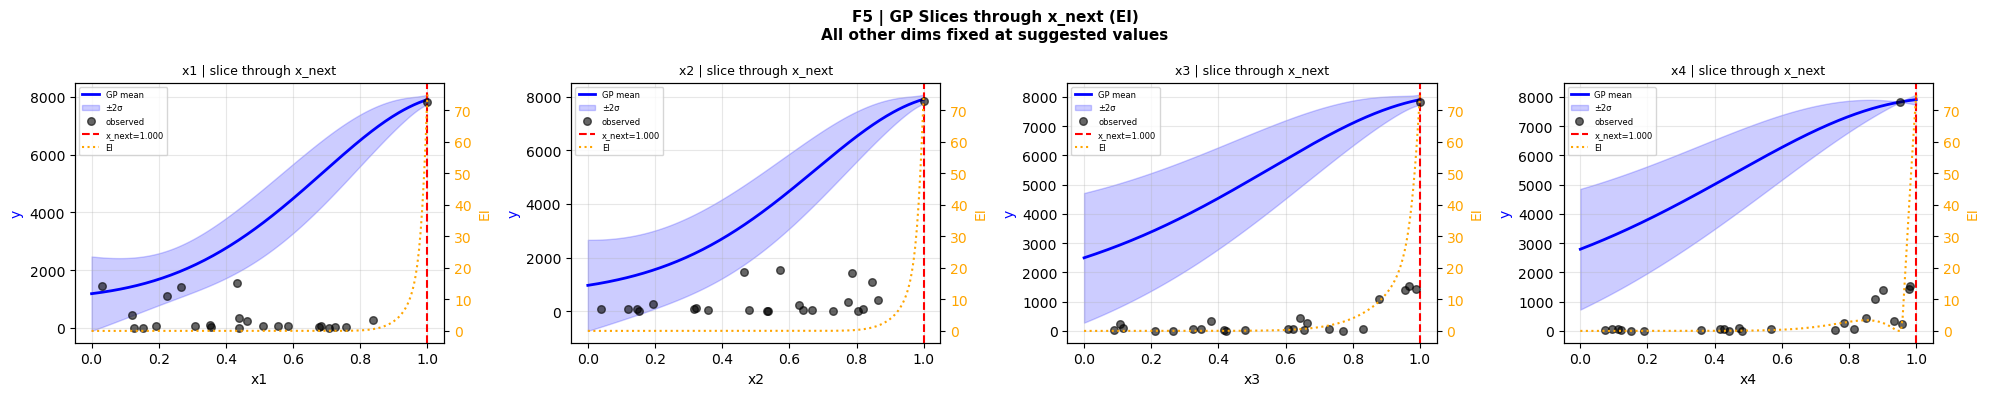

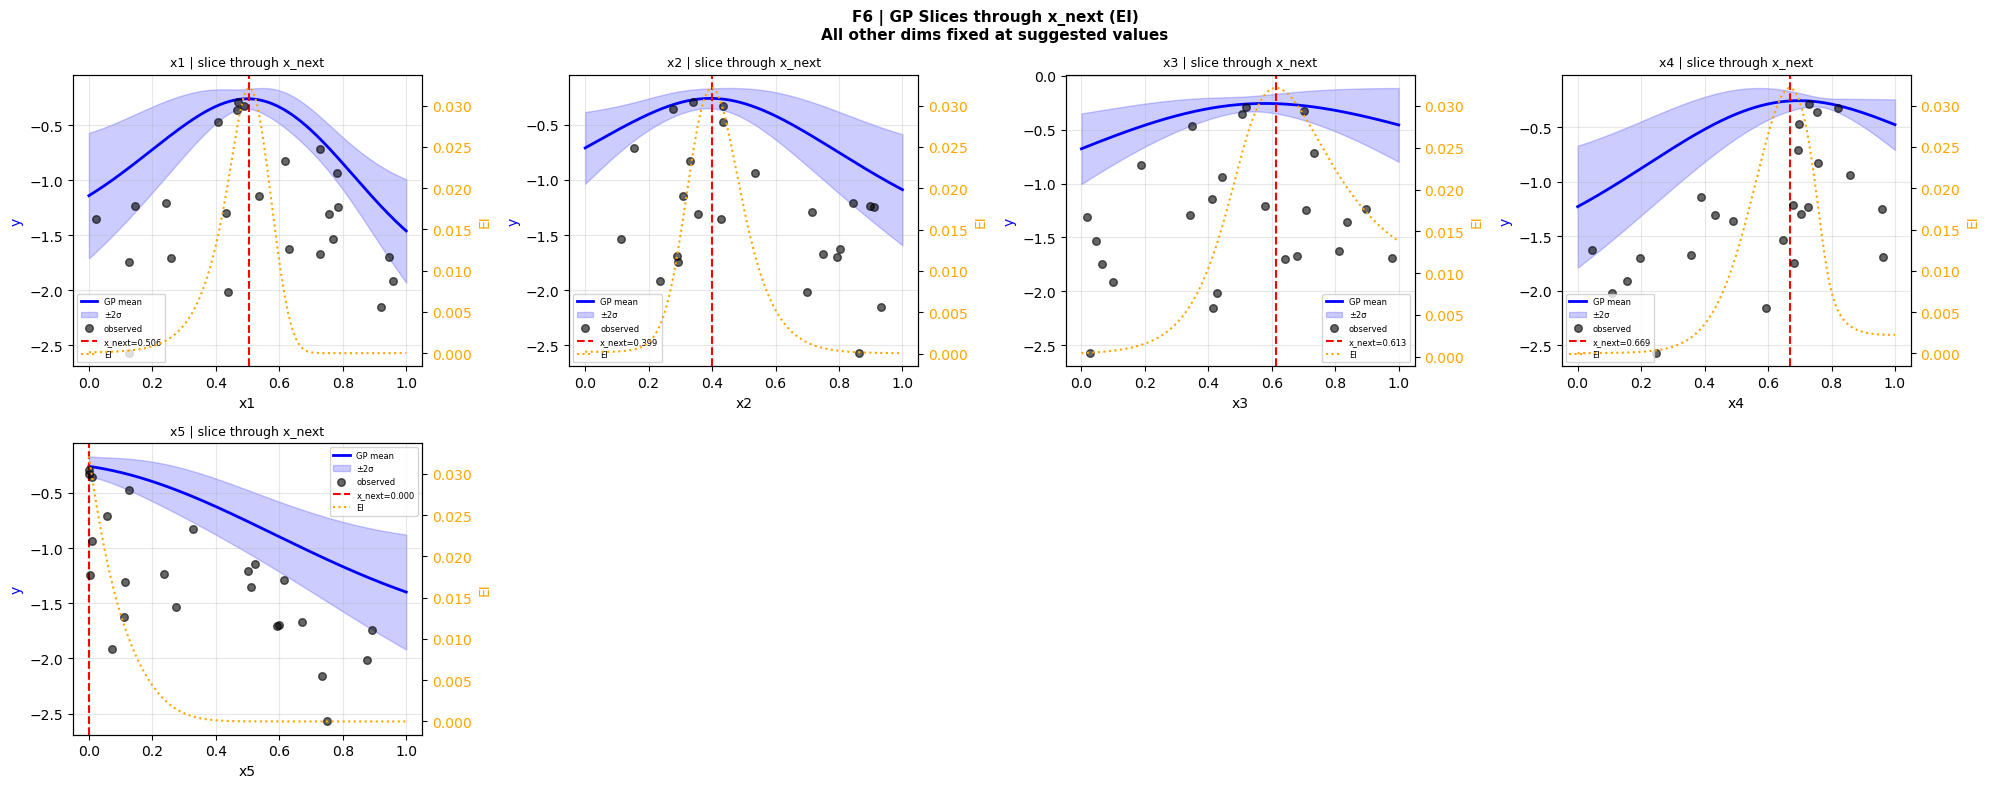

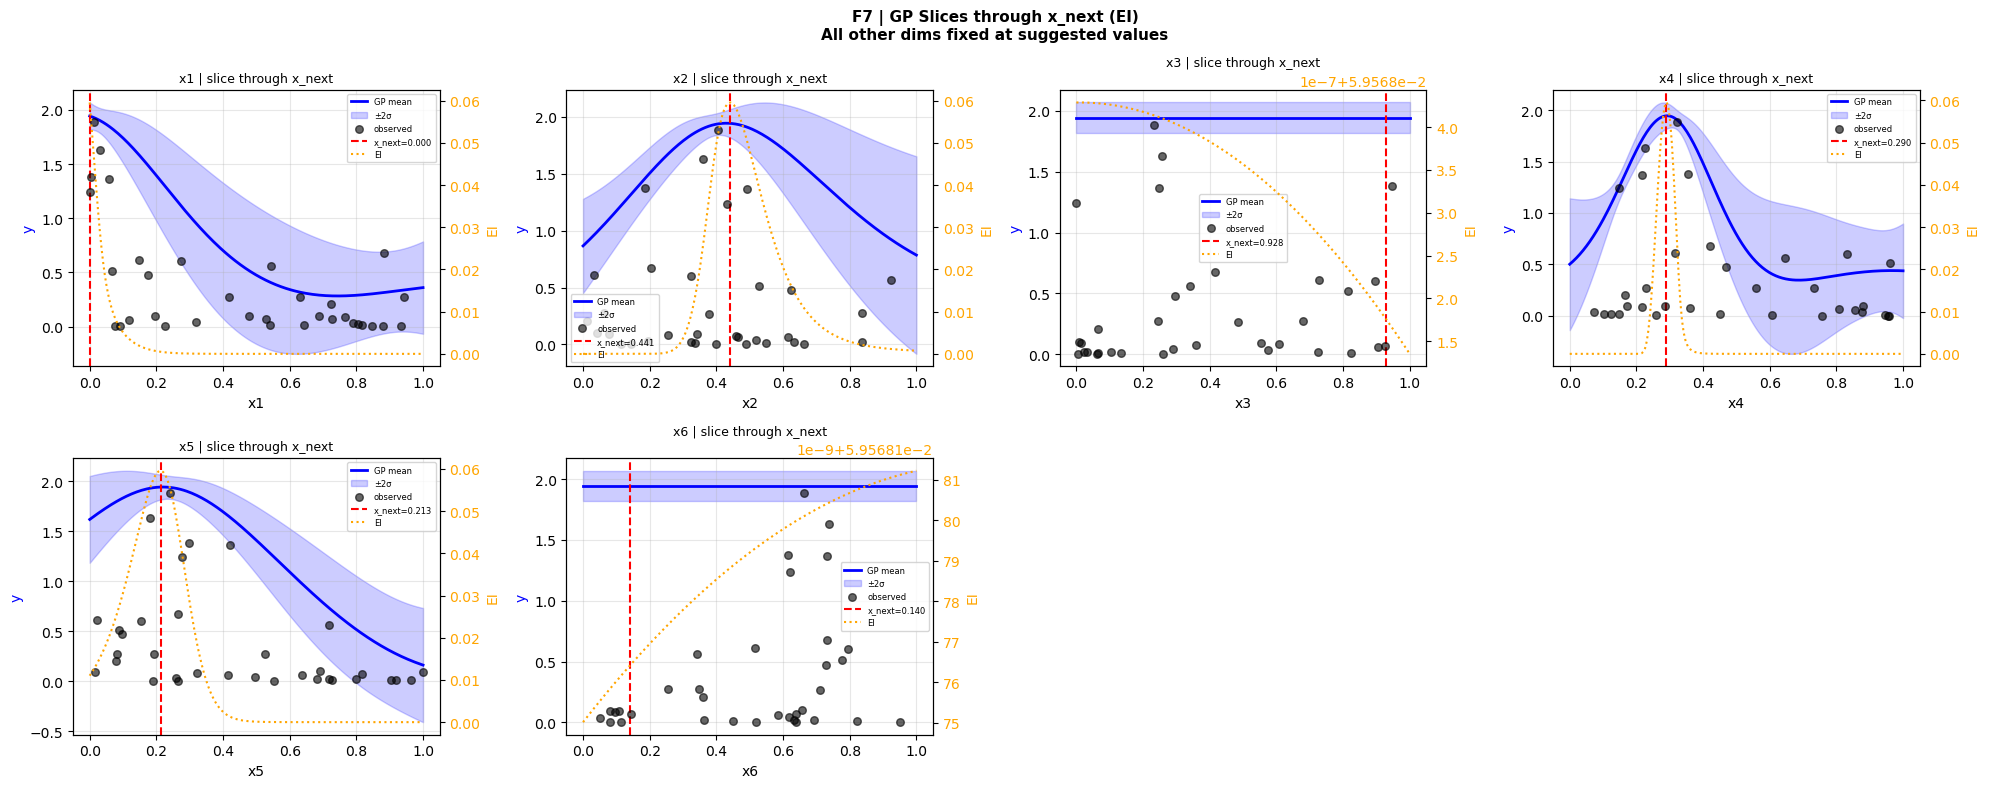

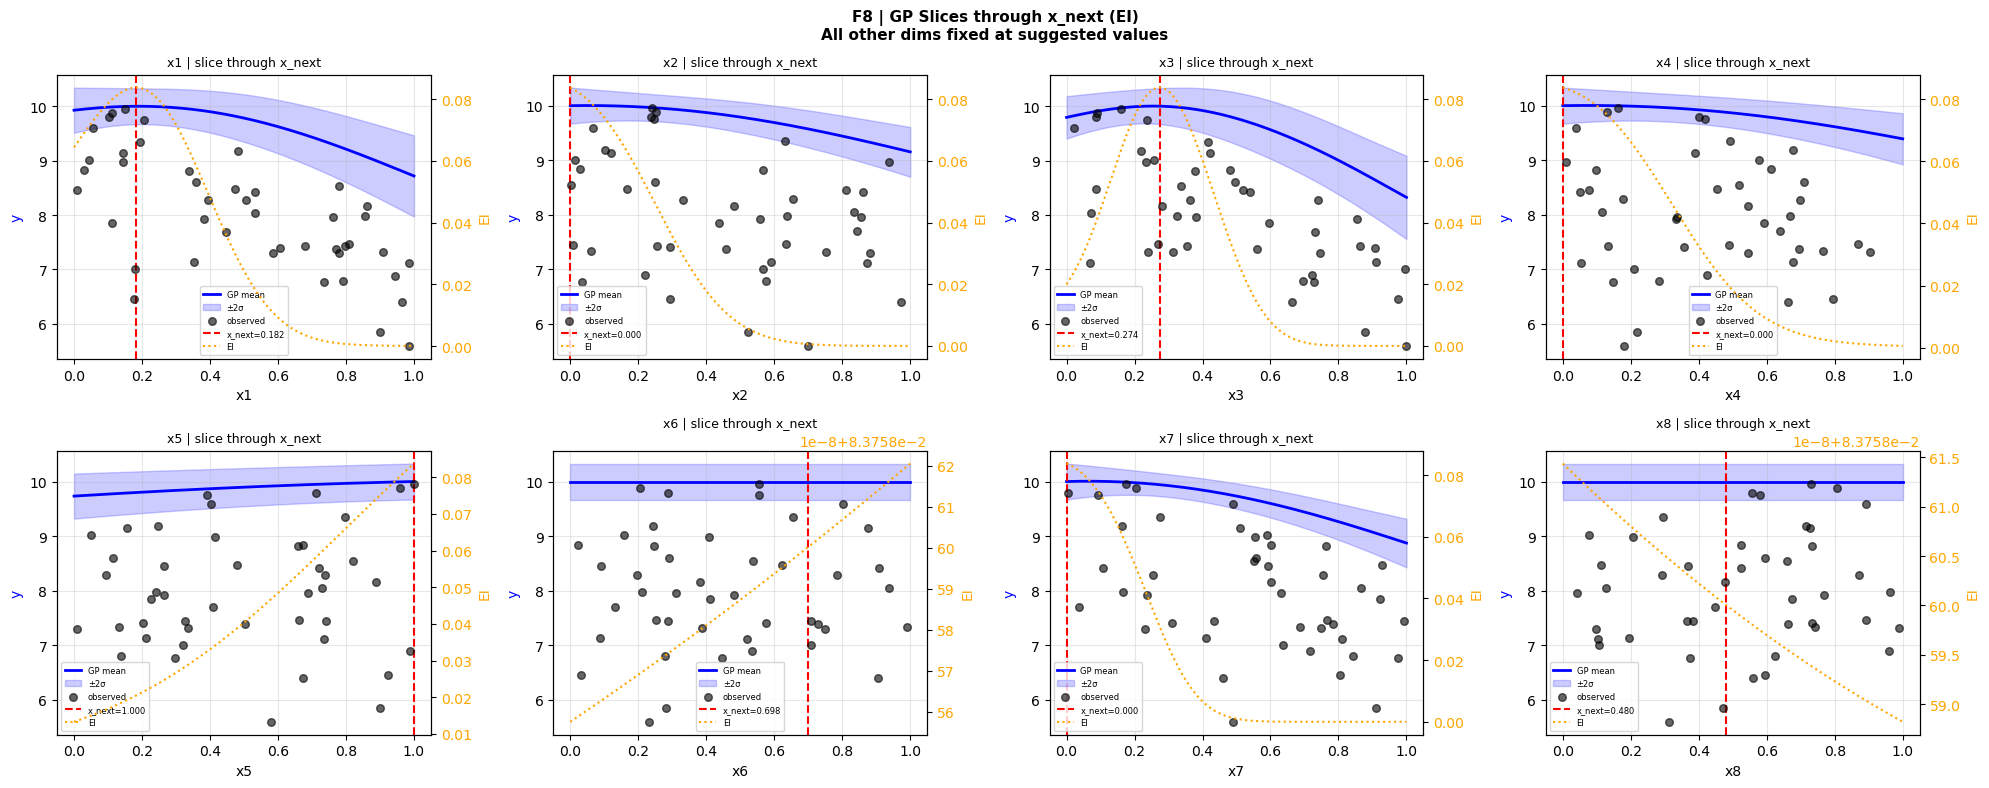

In [ ]:
# SLICING GP

def plot_gp_slices(fn_num, gp, df_best, n_points=200):
    X        = all_X[fn_num - 1]
    y        = all_y[fn_num - 1]
    n_dim    = X.shape[1]
    dim_cols = X.columns.tolist()


    best_row = df_best.iloc[fn_num - 1]
    sub      = best_row['submission']
    x_ref    = np.array([float(v) for v in sub.split('-')])
    acq      = best_row['acquisition']
    y_max    = float(best_row['y_max_so_far'])

    n_cols = min(4, n_dim)
    n_rows = int(np.ceil(n_dim / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(5*n_cols, 4*n_rows),
                             squeeze=False)

    t = np.linspace(1e-6, 0.999999, n_points)

    for idx, col in enumerate(dim_cols):
        row, col_idx = divmod(idx, n_cols)
        ax1 = axes[row][col_idx]

        X_slice = np.tile(x_ref, (n_points, 1))
        X_slice[:, idx] = t

        mu, sigma = gp.predict(X_slice, return_std=True)

  
        ax1.plot(t, mu, 'b-', linewidth=2, label='GP mean')
        ax1.fill_between(t, mu - 2*sigma, mu + 2*sigma,
                         alpha=0.2, color='blue', label='±2σ')
        ax1.scatter(X[col], y, color='black', s=30, zorder=5,
                    alpha=0.6, label='observed')
        ax1.axvline(x_ref[idx], color='red', linestyle='--',
                    linewidth=1.5, label=f'x_next={x_ref[idx]:.3f}')
        ax1.set_xlabel(col)
        ax1.set_ylabel('y', color='blue')
        ax1.set_title(f'{col} | slice through x_next', fontsize=9)
        ax1.grid(True, alpha=0.3)

        # ── Acquisition on twin axis
        ax2 = ax1.twinx()
        if acq == 'EI':
            a_vals = acq_EI(mu, sigma, y_max, all_y[fn_num - 1].values)
        elif acq == 'UCB':
            t_current = len(all_y[fn_num - 1])   
            d_current = all_X[fn_num - 1].shape[1]
            a_vals = acq_UCB(mu, sigma, y_max, all_y[fn_num - 1].values, t=t_current, d=d_current)

        else:
            a_vals = acq_PI(mu, sigma, y_max, all_y[fn_num - 1].values)

        ax2.plot(t, a_vals, color='orange', linewidth=1.5,
                 linestyle=':', label=f'{acq}')
        ax2.set_ylabel(acq, color='orange')
        ax2.tick_params(axis='y', labelcolor='orange')

        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1+lines2, labels1+labels2, fontsize=6)

    for idx in range(n_dim, n_rows * n_cols):
        r, c = divmod(idx, n_cols)
        axes[r][c].set_visible(False)

    plt.suptitle(f'F{fn_num} | GP Slices through x_next ({acq})\n'
                 f'All other dims fixed at suggested values',
                 fontweight='bold', fontsize=11)
    plt.tight_layout()
    plt.show()

# Usage
for fn in range(1, 9):
    plot_gp_slices(fn, gps[fn], df_best)

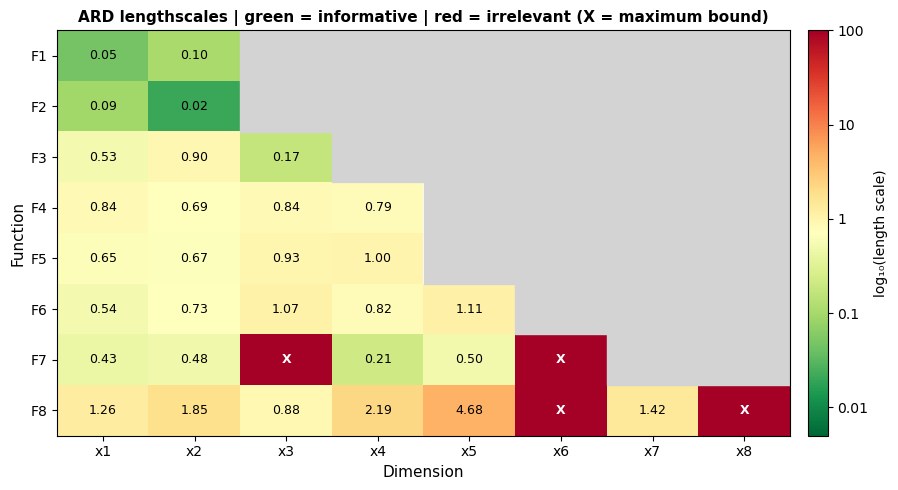

In [ ]:
# LENGTHSCALES HEATMAP

length_scale_df = []

for fn_num in range(1, 9):
    gp = gps[fn_num]
    ls = gp.kernel_.length_scale
    dim_cols = all_X[fn_num - 1].columns.tolist()
    
    row = {'function': fn_num, 'dimensions': len(dim_cols)}
    for col, l in zip(dim_cols, ls):
        row[col] = round(float(l), 4)
    length_scale_df.append(row)

df_ls = pd.DataFrame(length_scale_df).set_index('function')


def plot_lengthscale_heatmap(df_ls, threshold=10.0):
    # Extract only x columns
    x_cols = [c for c in df_ls.columns if c.startswith('x')]
    data = df_ls[x_cols].values.astype(float)
    
    # Log scale
    log_data = np.log10(np.where(np.isnan(data), np.nan, data))
    
    fig, ax = plt.subplots(figsize=(max(8, len(x_cols)*1.2), 5))
    
    # Mask NaN (dimensions that don't exist for that function)
    masked = np.ma.masked_invalid(log_data)
    
    im = ax.imshow(masked, cmap='RdYlGn_r', aspect='auto',
                   vmin=np.log10(0.005), vmax=np.log10(100))
    
    # Annotate cells
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            if not np.isnan(data[i, j]):
                val = data[i, j]
                label = f'{val:.2f}' if val < 10 else f'{val:.0f}'
                # Mark irrelevant dims with X
                marker = 'X' if val >= threshold else label
                color = 'white' if val >= threshold else 'black'
                ax.text(j, i, marker, ha='center', va='center',
                       fontsize=9, color=color, fontweight='bold' if val >= threshold else 'normal')
    
    ax.set_xticks(range(len(x_cols)))
    ax.set_xticklabels(x_cols, fontsize=10)
    ax.set_yticks(range(len(df_ls)))
    ax.set_yticklabels([f'F{fn}' for fn in df_ls.index], fontsize=10)
    ax.set_xlabel('Dimension', fontsize=11)
    ax.set_ylabel('Function', fontsize=11)
    ax.set_title('ARD lengthscales | green = informative | red = irrelevant (X = maximum bound)',
                fontweight='bold', fontsize=11)
    
    # Colorbar with original scale ticks
    cbar = fig.colorbar(im, ax=ax, pad=0.02)
    cbar.set_label('log₁₀(length scale)', fontsize=10)
    cbar.set_ticks([np.log10(v) for v in [0.01, 0.1, 1, 10, 100]])
    cbar.set_ticklabels(['0.01', '0.1', '1', '10', '100'])
    
    # Grey out non-existent dimensions
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            if np.isnan(data[i, j]):
                ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1,
                             fill=True, color='lightgrey', zorder=0))
    
    plt.tight_layout()
    plt.show()

plot_lengthscale_heatmap(df_ls)

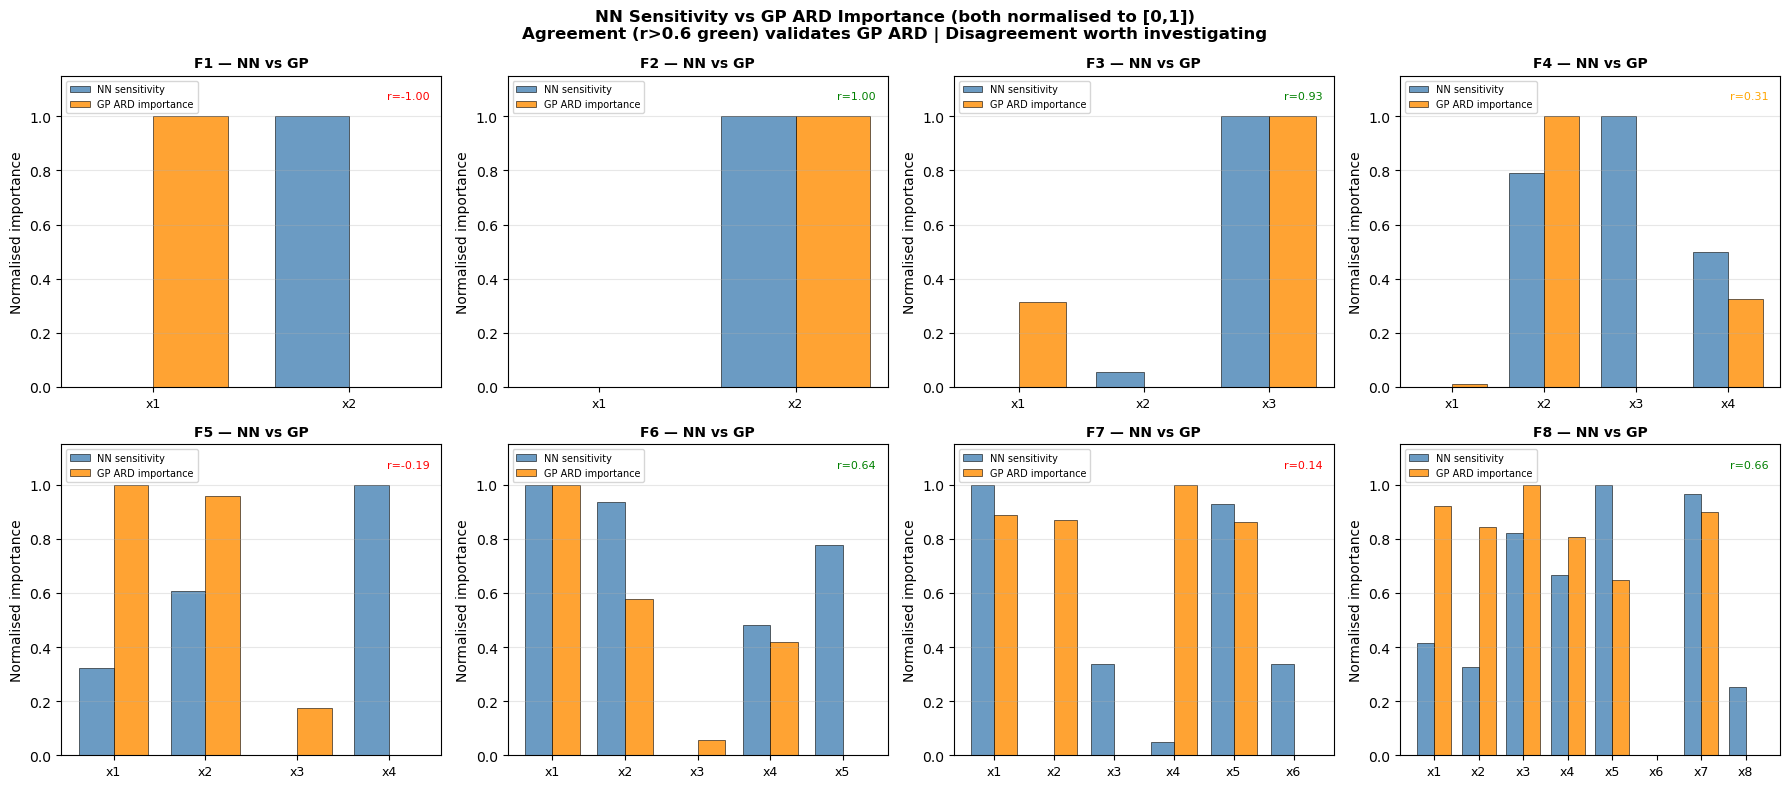

In [ ]:
# ── NN SENSITIVITY vs ARD LENGTH SCALES ──────────────────────────────────────
# Side-by-side: what the NN thinks matters vs what the GP learned.
# Agreement validates the GP's ARD; disagreement flags interesting tension.

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for fn_num in range(1, 9):
    ax = axes[fn_num - 1]
    dim_cols = all_X[fn_num - 1].columns.tolist()
    n_dim    = len(dim_cols)

    nn_imp = guide_nn_imp.get(fn_num, np.ones(n_dim) / n_dim)

    # ARD length scales from fitted GP (log10, inverted → higher = more important)
    gp = gps[fn_num]
    ls = gp.kernel_.length_scale
    # Inverse log10: smaller length scale = GP varies faster = more important
    ls_log_inv = -np.log10(np.clip(ls, 1e-3, 100.0))
    ls_range = ls_log_inv.max() - ls_log_inv.min()
    ls_norm  = (ls_log_inv - ls_log_inv.min()) / (ls_range + 1e-12)

    x_pos = np.arange(n_dim)
    width = 0.38

    bars_nn  = ax.bar(x_pos - width/2, nn_imp, width,
                      label='NN sensitivity', color='steelblue', alpha=0.8,
                      edgecolor='k', linewidth=0.5)
    bars_gp  = ax.bar(x_pos + width/2, ls_norm, width,
                      label='GP ARD importance', color='darkorange', alpha=0.8,
                      edgecolor='k', linewidth=0.5)

    ax.set_xticks(x_pos)
    ax.set_xticklabels(dim_cols, fontsize=9)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel('Normalised importance')
    ax.set_title(f'F{fn_num} — NN vs GP', fontweight='bold', fontsize=10)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3, axis='y')

    # Correlation annotation
    if n_dim > 1:
        corr = np.corrcoef(nn_imp, ls_norm)[0, 1]
        ax.text(0.97, 0.95, f'r={corr:.2f}', transform=ax.transAxes,
                ha='right', va='top', fontsize=8,
                color='green' if corr > 0.6 else ('orange' if corr > 0.3 else 'red'))

fig.suptitle(
    'NN Sensitivity vs GP ARD Importance (both normalised to [0,1])\n'
    'Agreement (r>0.6 green) validates GP ARD | Disagreement worth investigating',
    fontweight='bold', fontsize=12
)
plt.tight_layout()
plt.show()

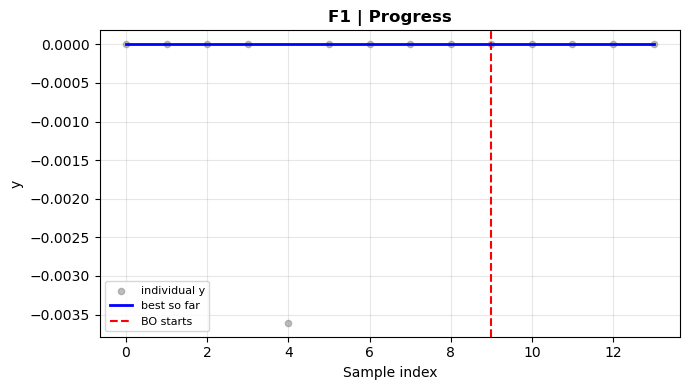

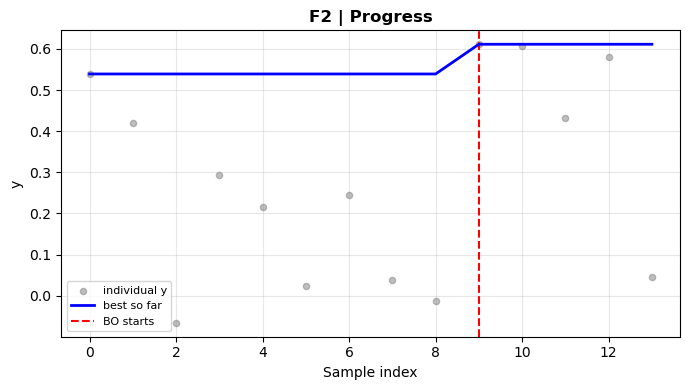

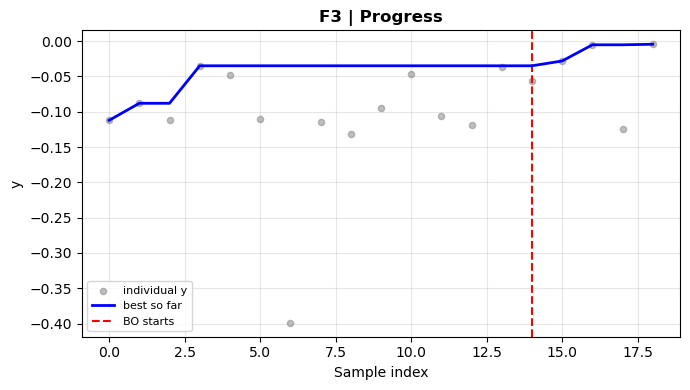

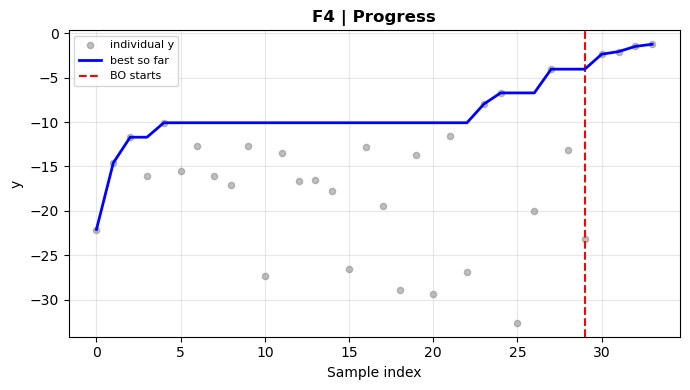

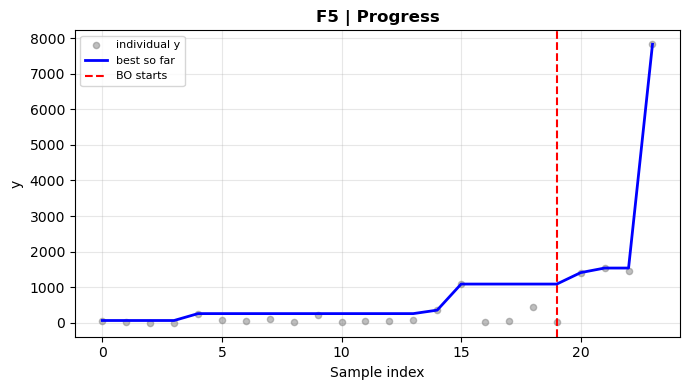

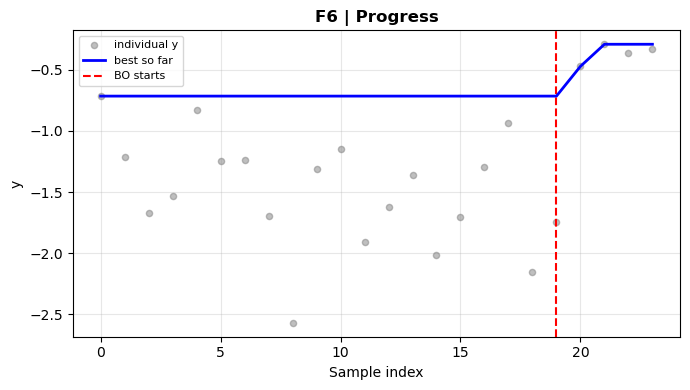

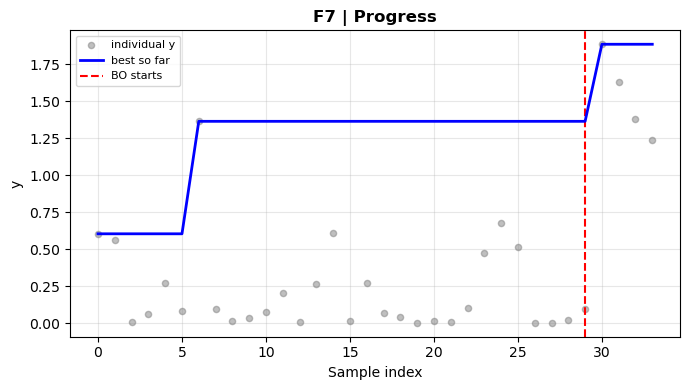

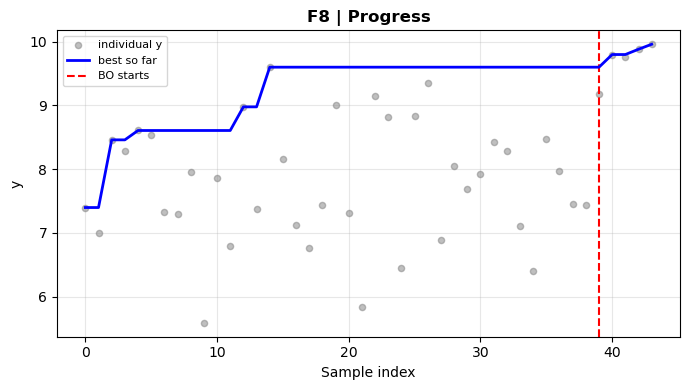

Function           Best y    At index
-------------------------------------
F1                 0.0000           2
F2                 0.6112           9
F3                -0.0043          18
F4                -1.2175          33
F5              7829.1268          23
F6                -0.2896          21
F7                 1.8861          30
F8                 9.9577          43


In [ ]:
# TRACKING PROGRESS

def plot_progress(fn_num):
    y = all_y[fn_num - 1].values
    n_initial = [10, 10, 15, 30, 20, 20, 30, 40][fn_num - 1]
    
    running_max = np.maximum.accumulate(y)
    iterations = np.arange(len(y))
    
    fig, ax = plt.subplots(figsize=(7, 4))
    
    ax.scatter(iterations, y, color='grey', s=20, alpha=0.5, 
               zorder=2, label='individual y')
    
    ax.plot(iterations, running_max, color='blue', 
            linewidth=2, zorder=3, label='best so far')
    
    ax.axvline(n_initial - 1, color='red', linestyle='--', 
               linewidth=1.5, label='BO starts')
    
    ax.set_xlabel('Sample index')
    ax.set_ylabel('y')
    ax.set_title(f'F{fn_num} | Progress', fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

for fn in range(1, 9):
    plot_progress(fn)

# SUMMARY OF BEST Y SO FAR FOR ALL FUNCTIONS

print(f"{'Function':<10}{'Best y':>15}{'At index':>12}")
print("-" * 37)

for fn_num in range(1, 9):
    y = all_y[fn_num - 1].values
    best_y = np.max(y)
    best_idx = np.argmax(y)
    print(f"F{fn_num:<9}{best_y:>15.4f}{best_idx:>12}")

F1 | RBF (no ARD): RBF(length_scale=0.0464)
F1 | RBF (ARD): RBF(length_scale=[0.0391, 0.107])
F1 | Matérn 5/2 (ARD): Matern(length_scale=[100, 0.0332], nu=2.5)


/home/omkarsjoshi/miniconda3/envs/ICL/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


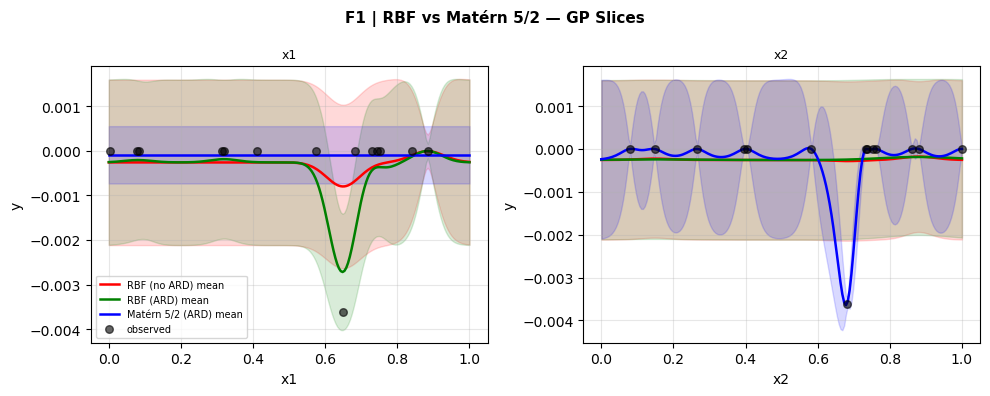

F2 | RBF (no ARD): RBF(length_scale=0.00394)
F2 | RBF (ARD): RBF(length_scale=[29.5, 0.00753])
F2 | Matérn 5/2 (ARD): Matern(length_scale=[0.0718, 0.0204], nu=2.5)


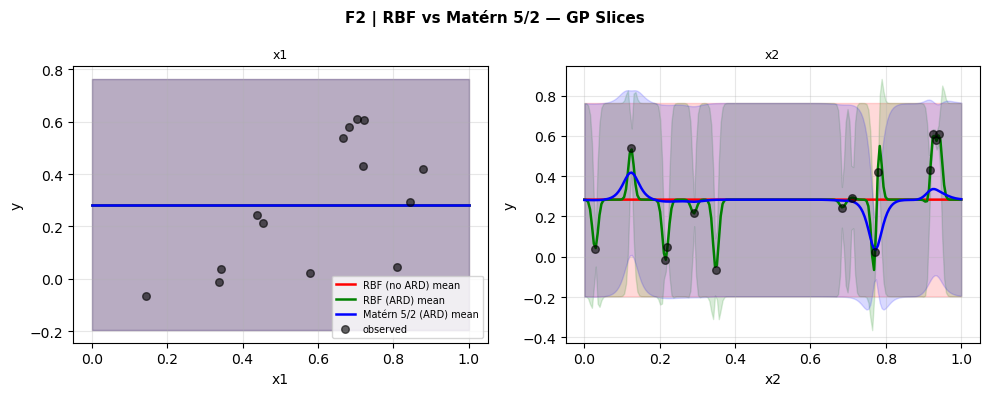

F3 | RBF (no ARD): RBF(length_scale=0.223)
F3 | RBF (ARD): RBF(length_scale=[0.435, 0.559, 0.135])
F3 | Matérn 5/2 (ARD): Matern(length_scale=[100, 1.29, 0.0706], nu=2.5)


/home/omkarsjoshi/miniconda3/envs/ICL/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


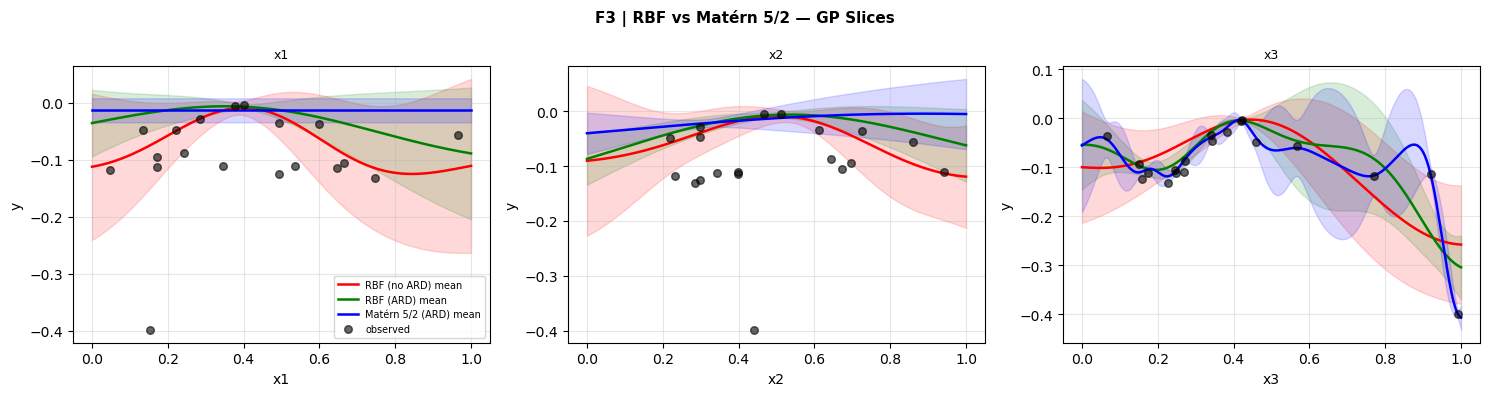

F4 | RBF (no ARD): RBF(length_scale=0.528)
F4 | RBF (ARD): RBF(length_scale=[0.575, 0.476, 0.559, 0.548])
F4 | Matérn 5/2 (ARD): Matern(length_scale=[0.842, 0.688, 0.843, 0.79], nu=2.5)


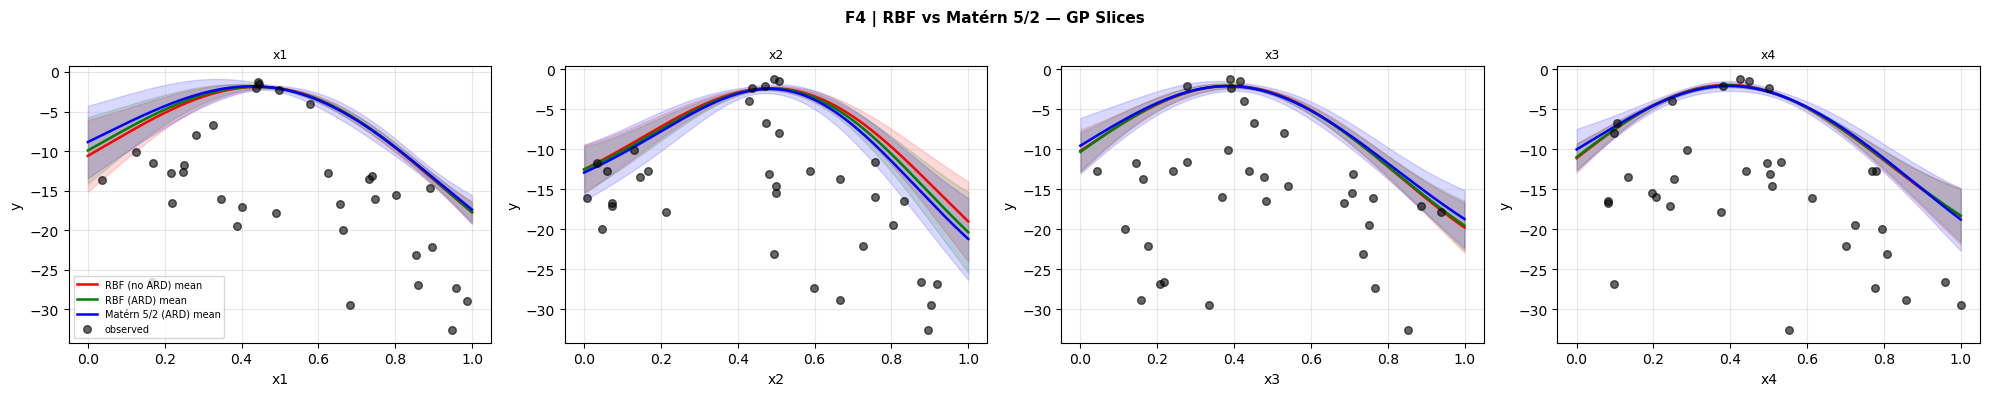

F5 | RBF (no ARD): RBF(length_scale=0.581)
F5 | RBF (ARD): RBF(length_scale=[0.156, 1.37, 0.863, 2.67])
F5 | Matérn 5/2 (ARD): Matern(length_scale=[0.147, 22.5, 1.37, 4.14], nu=2.5)


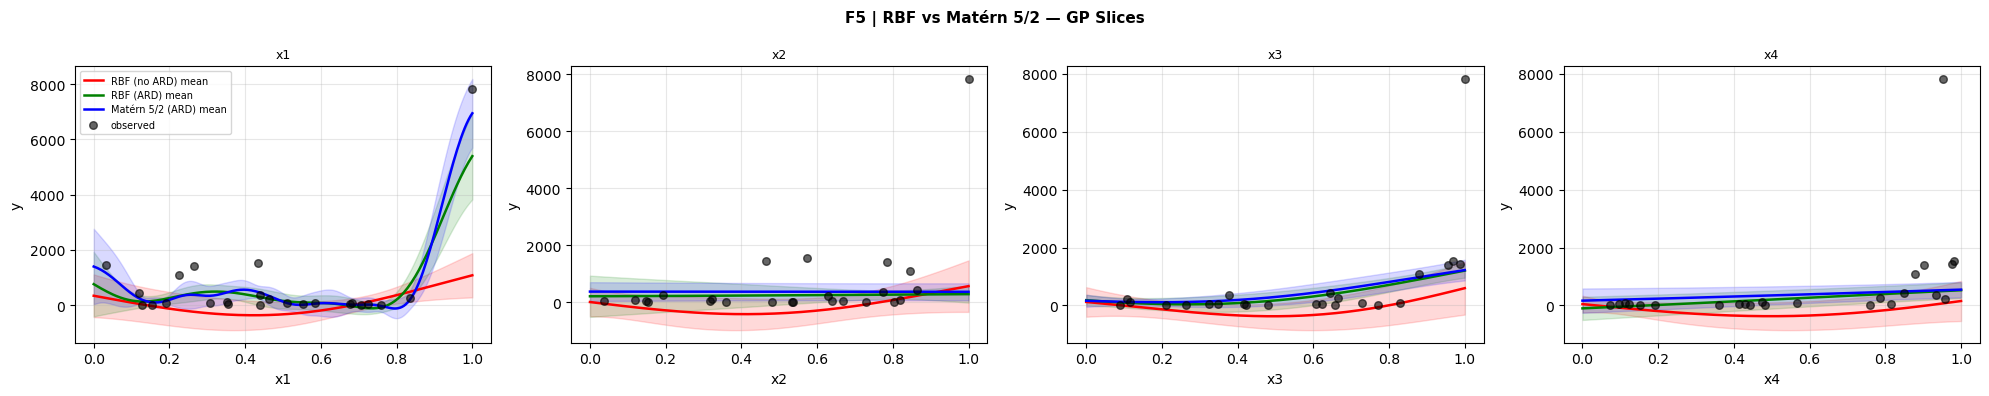

F6 | RBF (no ARD): RBF(length_scale=0.0117)
F6 | RBF (ARD): RBF(length_scale=[0.42, 0.443, 0.664, 0.588, 0.923])
F6 | Matérn 5/2 (ARD): Matern(length_scale=[0.536, 0.729, 1.07, 0.819, 1.11], nu=2.5)


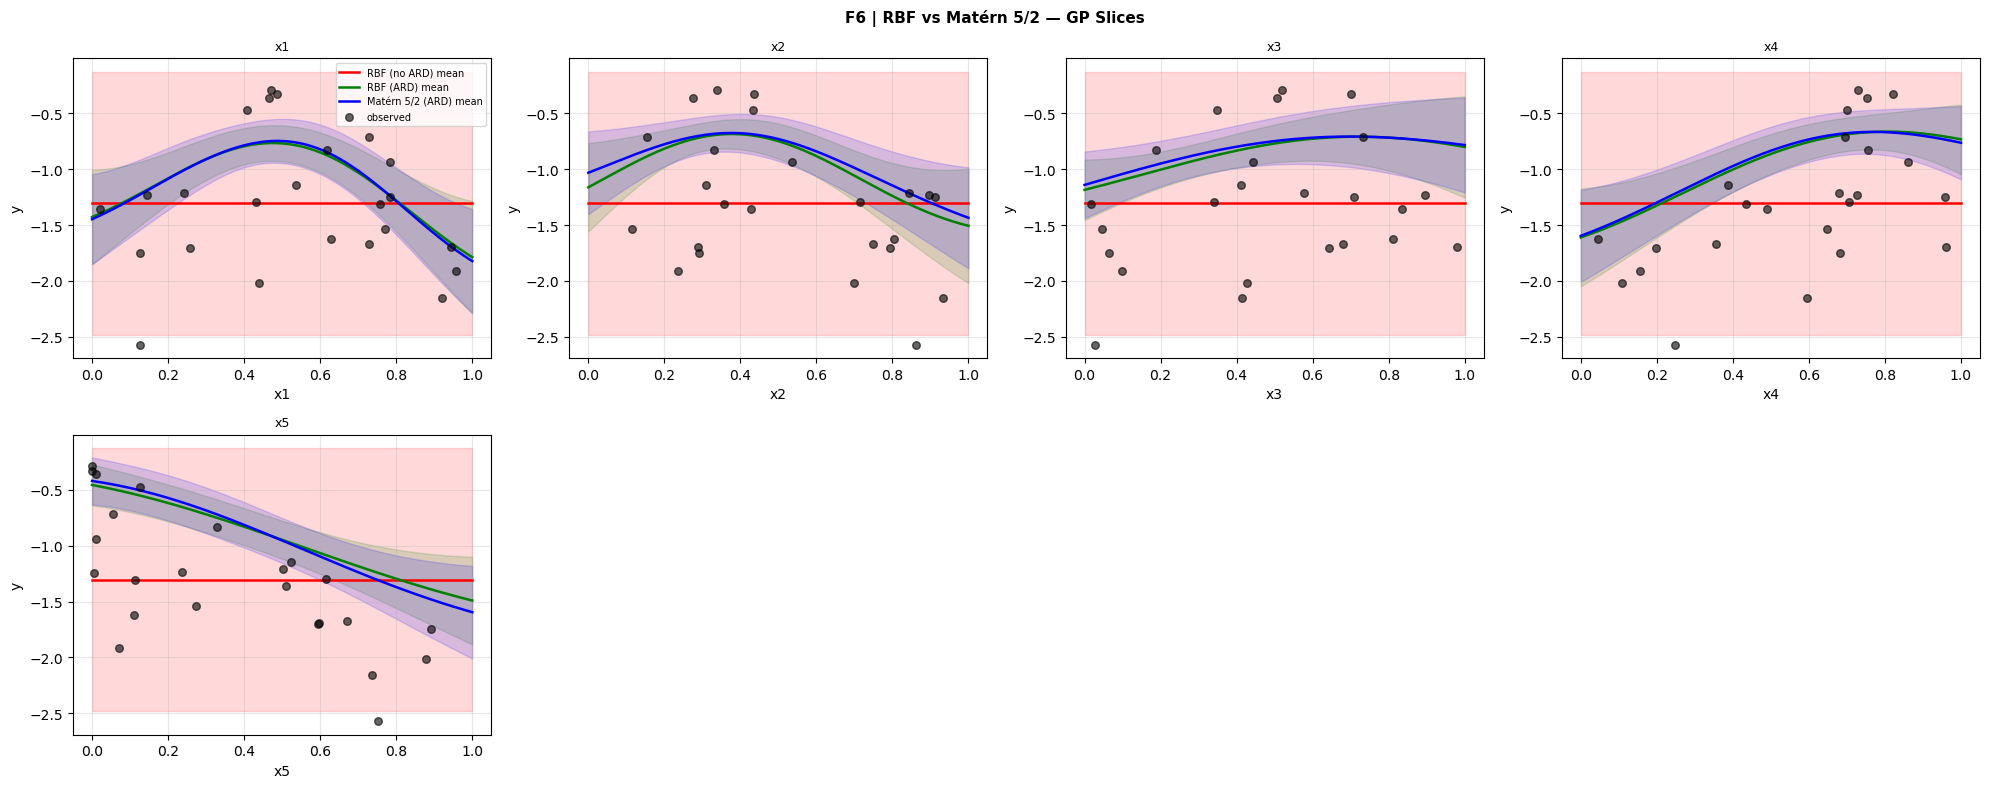

F7 | RBF (no ARD): RBF(length_scale=0.333)
F7 | RBF (ARD): RBF(length_scale=[0.411, 0.318, 100, 0.177, 0.546, 100])


/home/omkarsjoshi/miniconda3/envs/ICL/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 2 of parameter length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/omkarsjoshi/miniconda3/envs/ICL/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 5 of parameter length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/omkarsjoshi/miniconda3/envs/ICL/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/omkarsjoshi/miniconda3

F7 | Matérn 5/2 (ARD): Matern(length_scale=[0.208, 100, 1.85, 0.233, 0.5, 100], nu=2.5)


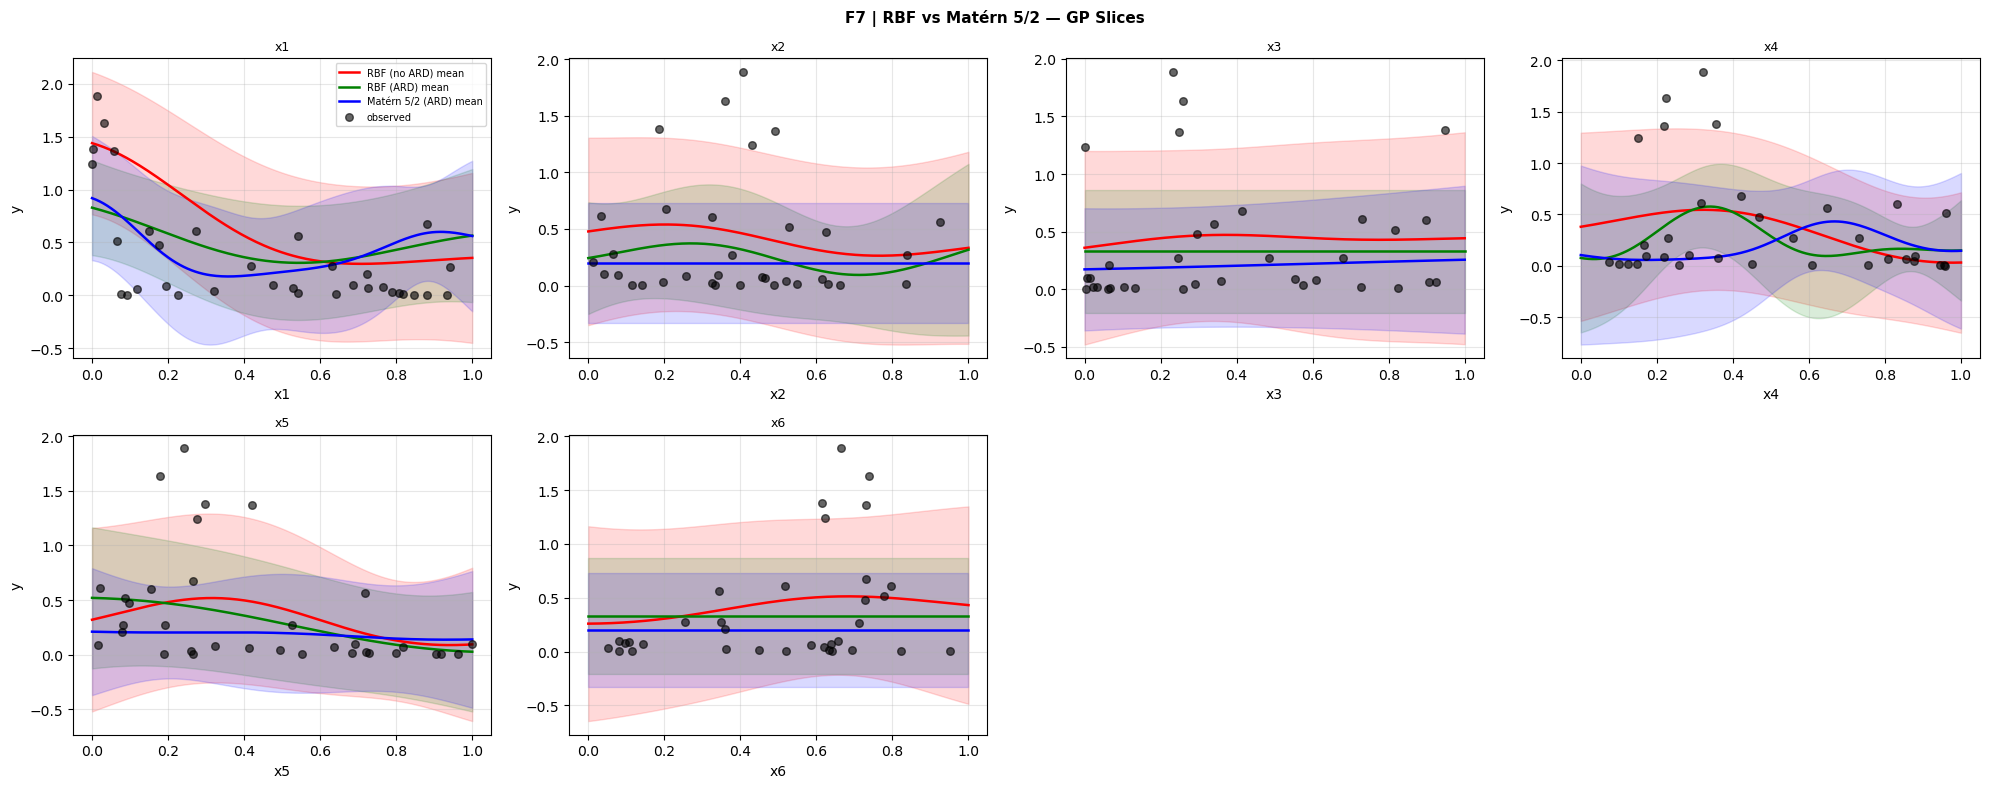

F8 | RBF (no ARD): RBF(length_scale=0.99)


/home/omkarsjoshi/miniconda3/envs/ICL/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 5 of parameter length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/omkarsjoshi/miniconda3/envs/ICL/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 7 of parameter length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


F8 | RBF (ARD): RBF(length_scale=[0.881, 1.15, 0.448, 1.64, 3.46, 100, 0.899, 100])


/home/omkarsjoshi/miniconda3/envs/ICL/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 5 of parameter length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/omkarsjoshi/miniconda3/envs/ICL/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 7 of parameter length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


F8 | Matérn 5/2 (ARD): Matern(length_scale=[1.26, 1.85, 0.876, 2.19, 4.67, 100, 1.42, 100], nu=2.5)


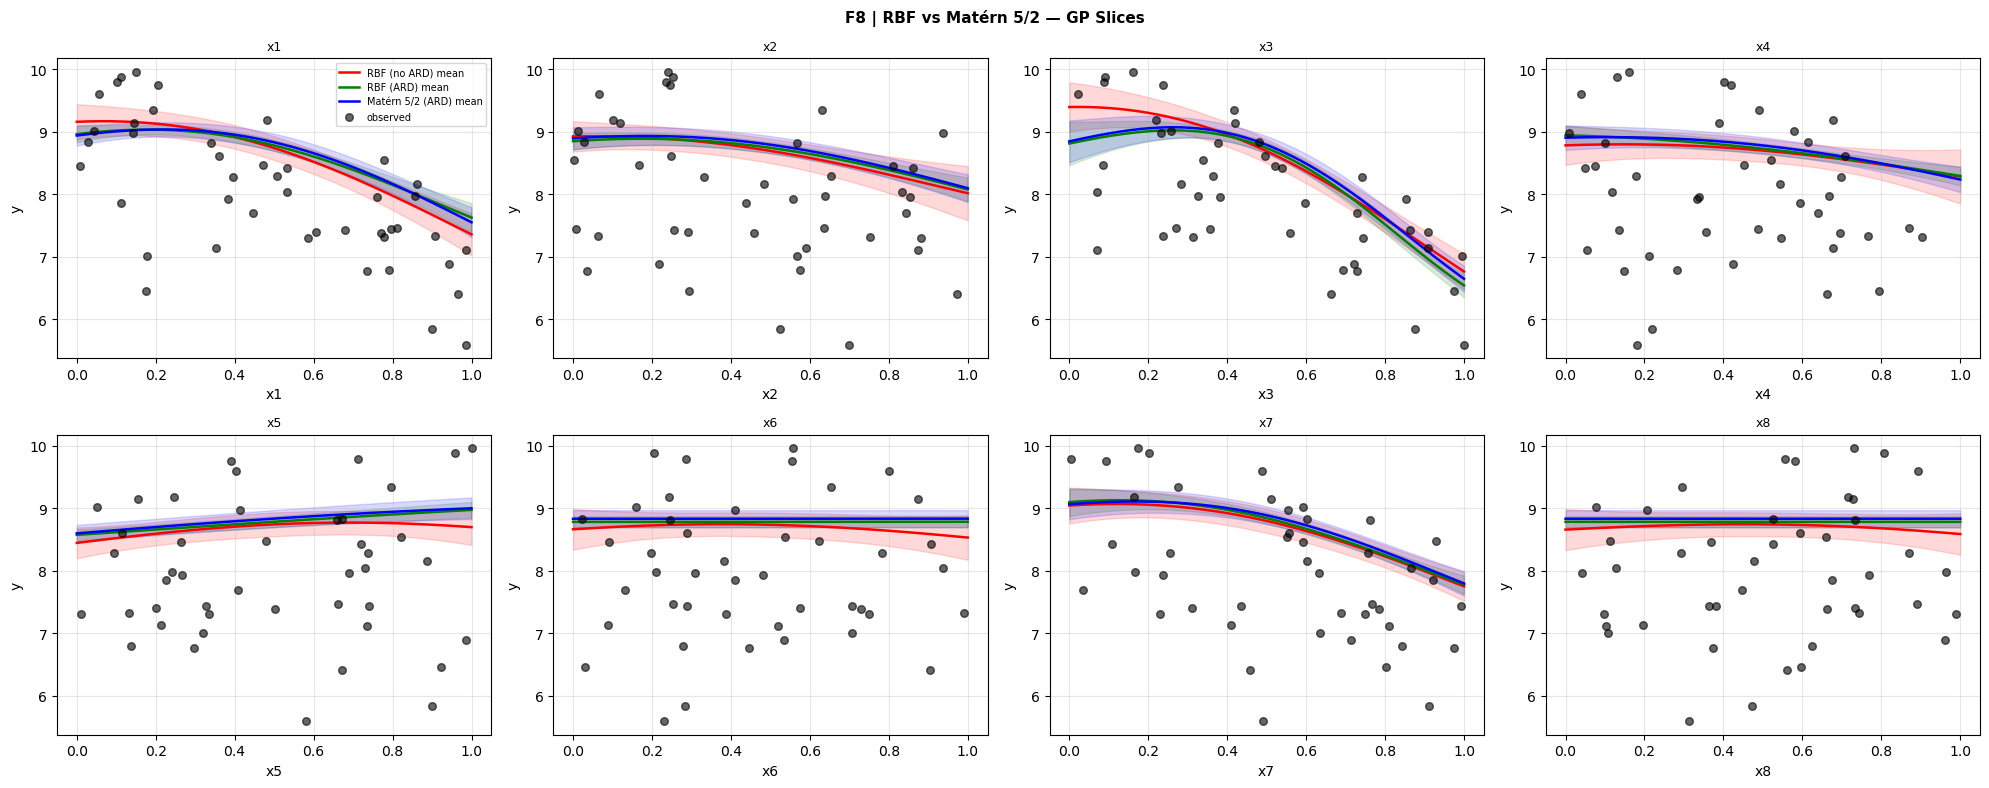

In [ ]:
# COMPARE KERNELS ON GP SLICES

def compare_kernels(fn_num, n_candidates=5000):
    X = all_X[fn_num - 1].values
    Y = all_y[fn_num - 1].values
    n_dim = X.shape[1]
    dim_cols = all_X[fn_num - 1].columns.tolist()

    kernels = {
        'RBF (no ARD)':     RBF(length_scale=1.0, 
                                length_scale_bounds=(1e-3, 100.0)),
        'RBF (ARD)':        RBF(length_scale=np.ones(n_dim), 
                                length_scale_bounds=(1e-3, 100.0)),
        'Matérn 5/2 (ARD)': Matern(length_scale=np.ones(n_dim), 
                                    length_scale_bounds=(1e-3, 100.0), nu=2.5)
    }

    gps_local = {}
    for name, kernel in kernels.items():
        gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6,
                                       n_restarts_optimizer=max(5, 2*n_dim),
                                       normalize_y=True)
        gp.fit(X, Y)
        gps_local[name] = gp
        print(f'F{fn_num} | {name}: {gp.kernel_}')

    x_ref = np.mean(all_X[fn_num - 1].values, axis=0)  # central slice
    t = np.linspace(1e-6, 0.999999, 200)

    n_cols = min(4, n_dim)
    n_rows = int(np.ceil(n_dim / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(5*n_cols, 4*n_rows),
                             squeeze=False)

    colors = {
        'RBF (no ARD)':     'red',
        'RBF (ARD)':        'green',
        'Matérn 5/2 (ARD)': 'blue'
    }

    for idx, col in enumerate(dim_cols):
        row, col_idx = divmod(idx, n_cols)
        ax = axes[row][col_idx]

        for name, gp in gps_local.items():  # ← fixed
            X_slice = np.tile(x_ref, (200, 1))
            X_slice[:, idx] = t
            mu, sigma = gp.predict(X_slice, return_std=True)
            c = colors[name]
            ax.plot(t, mu, color=c, linewidth=1.8, label=f'{name} mean')
            ax.fill_between(t, mu - 2*sigma, mu + 2*sigma,
                           alpha=0.15, color=c)

        ax.scatter(all_X[fn_num-1][col], all_y[fn_num-1],
                  color='black', s=30, zorder=5, alpha=0.6, label='observed')
        ax.set_xlabel(col)
        ax.set_ylabel('y')
        ax.set_title(f'{col}', fontsize=9)
        ax.grid(True, alpha=0.3)
        if idx == 0:
            ax.legend(fontsize=7)

    for idx in range(n_dim, n_rows * n_cols):
        r, c = divmod(idx, n_cols)
        axes[r][c].set_visible(False)

    plt.suptitle(f'F{fn_num} | RBF vs Matérn 5/2 — GP Slices',
                fontweight='bold', fontsize=11)
    plt.tight_layout()
    plt.show()

for fn_num in range(1, 9):
    compare_kernels(fn_num)

In [ ]:
# CONVERGENCE CHECK/SWITCHING
def is_stalled(y, n_initial, window=3, rel_thresh=0.01):
    post_bo = y[n_initial:]
    if len(post_bo) < window + 1:
        return False
    running_max = np.maximum.accumulate(post_bo)
    recent_best = running_max[-1]
    prior_best = running_max[-window-1]
    denom = max(abs(prior_best), 1e-6)
    return (recent_best - prior_best) <= rel_thresh * denom

n_initials = [10, 10, 15, 30, 20, 20, 30, 40]
for fn in range(1, 9):
    y = all_y[fn - 1].values
    stalled = is_stalled(y, n_initials[fn - 1])
    print(f'F{fn}: {"STALLED" if stalled else "improving"}')

F1: STALLED
F2: STALLED
F3: improving
F4: improving
F5: improving
F6: improving
F7: STALLED
F8: improving


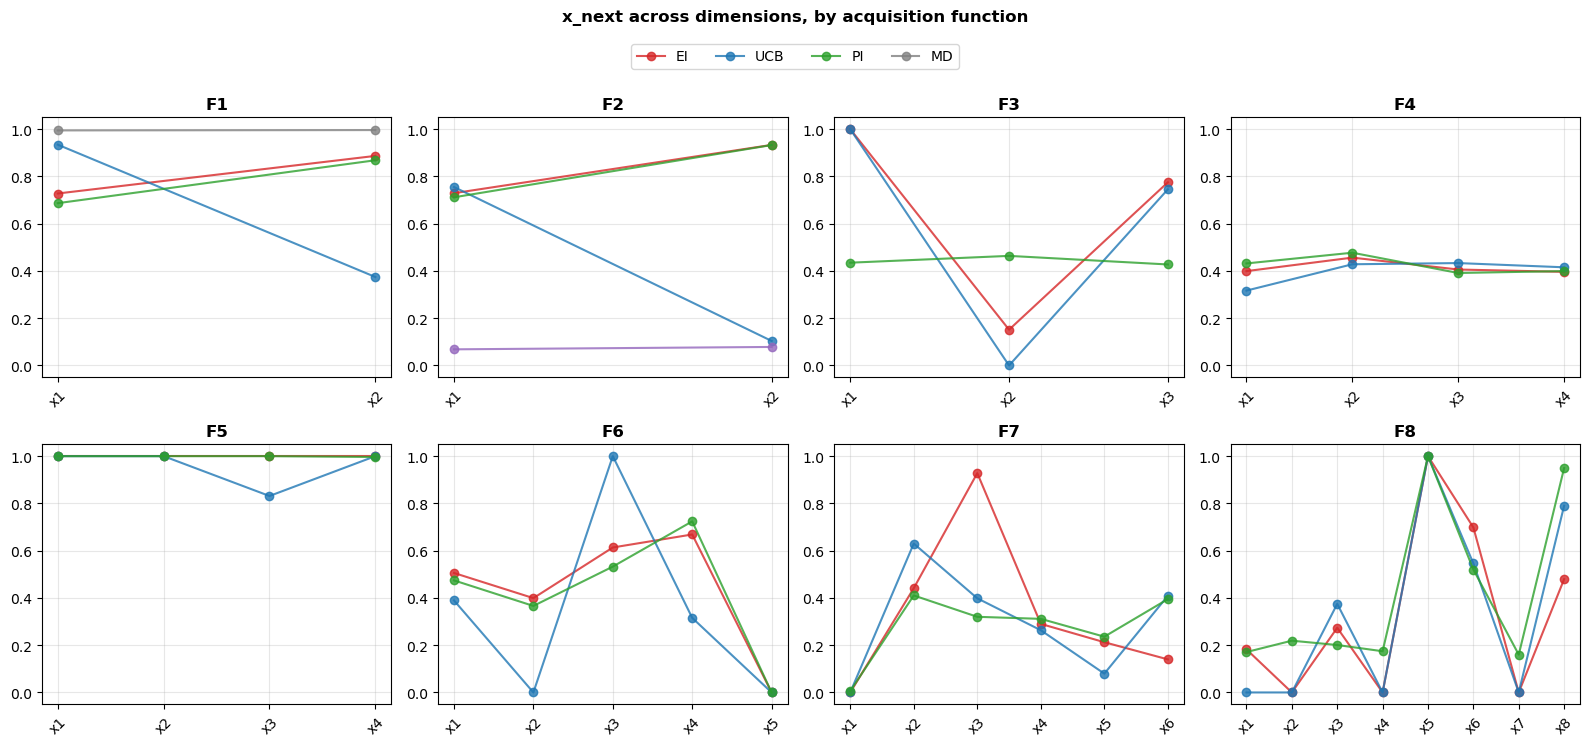

In [ ]:
#'# ACQUISITION FUNCTION ALIGNMENT ON PARALLEL COORDINATE PLOT

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.ravel()

colors = {'EI': 'tab:red', 'UCB': 'tab:blue', 'PI': 'tab:green', 'TS': 'tab:purple'}
all_suggested_cols = [f'x{i}_suggested' for i in range(1, 9)]

for fn in range(1, 9):
    ax = axes[fn - 1]
    df_fn = df_all[df_all['function'] == fn]
    n_dim = int(df_fn['dimensions'].iloc[0])
    cols = all_suggested_cols[:n_dim]
    dim_labels = [c.replace('_suggested', '') for c in cols]

    for _, row in df_fn.iterrows():
        acq = row['acquisition']
        values = row[cols].astype(float).values
        ax.plot(range(n_dim), values, 'o-', label=acq,
                color=colors.get(acq, 'grey'), alpha=0.8)

    ax.set_xticks(range(n_dim))
    ax.set_xticklabels(dim_labels, rotation=45)
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(f'F{fn}', fontweight='bold')
    ax.grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
fig.legend(by_label.values(), by_label.keys(), loc='upper center', ncol=4, bbox_to_anchor=(0.5, 1.02))
fig.suptitle('x_next across dimensions, by acquisition function', y=1.06, fontweight='bold')
plt.tight_layout()
plt.show()

Running LOO cross-validation...
  F1 (d=2, n=14)... R²=-0.488  ρ=0.020
  F2 (d=2, n=14)... R²=-0.294  ρ=-0.415
  F3 (d=3, n=19)... R²=-0.042  ρ=0.218
  F4 (d=4, n=34)... R²=0.945  ρ=0.971
  F5 (d=4, n=24)... R²=0.218  ρ=0.605
  F6 (d=5, n=24)... R²=0.738  ρ=0.872
  F7 (d=6, n=34)... R²=-0.329  ρ=0.096
  F8 (d=8, n=44)... R²=0.978  ρ=0.987

Saved → loo_predicted_vs_actual.png


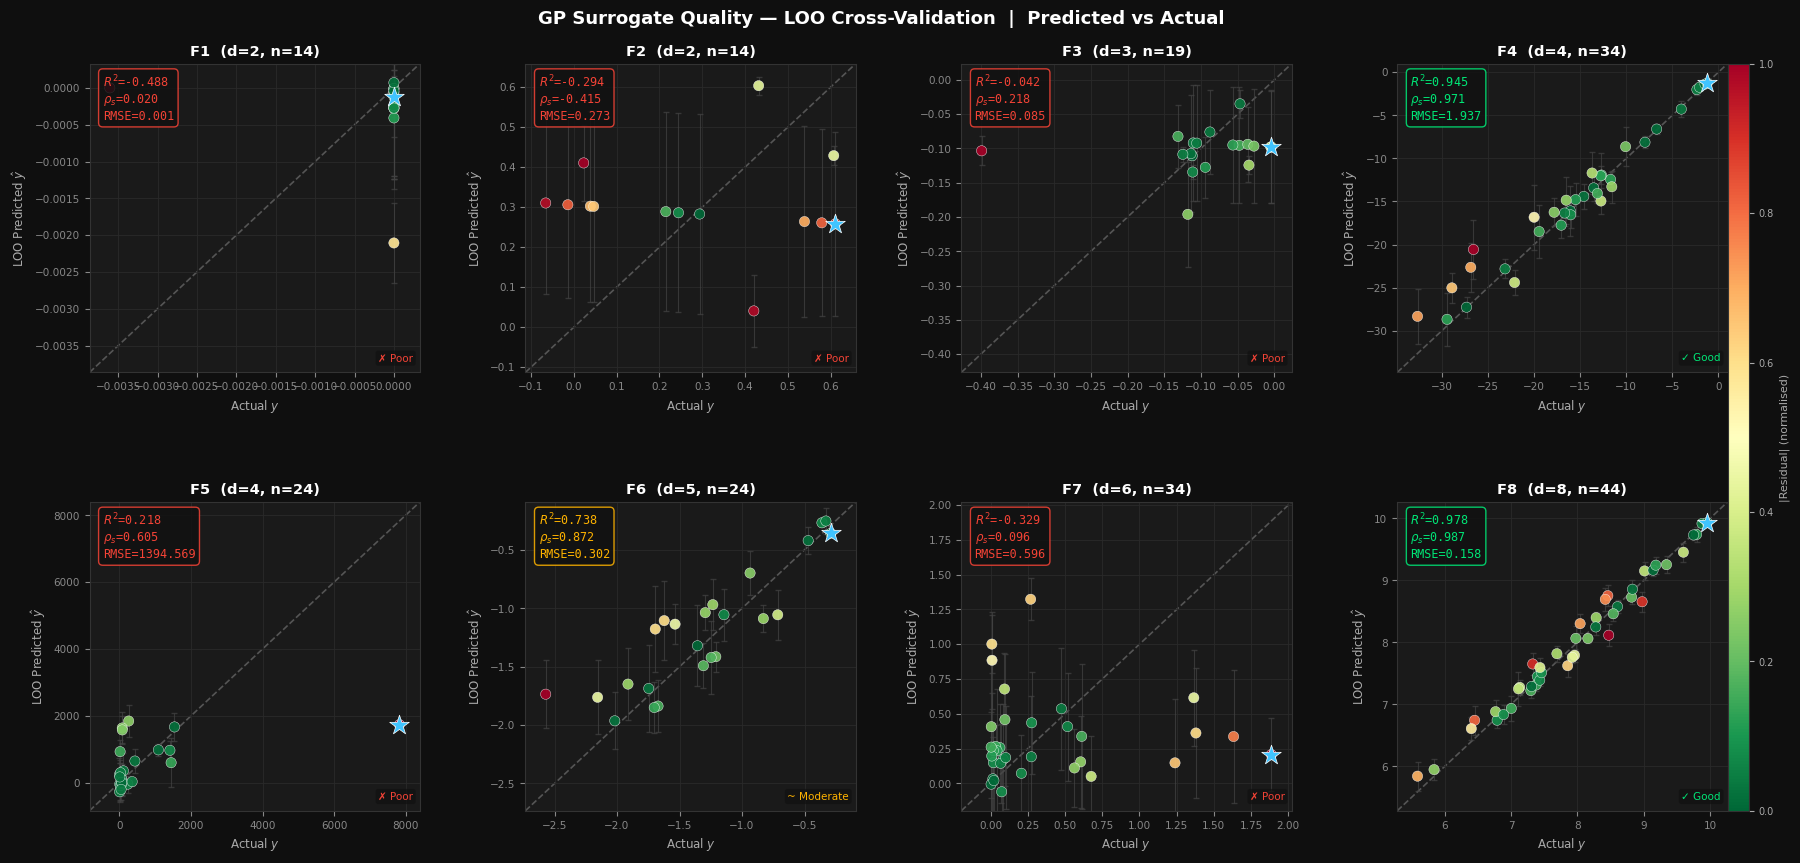

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
from sklearn.base import clone
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings('ignore')

# ── Config ────────────────────────────────────────────────────────────────────
DATA_DIR    = 'initial_data_5'          # path to your data folder
OUTPUT_PATH = 'loo_predicted_vs_actual.png'
ALPHA_F2    = 0.01                      # noisier GP for F2
N_RESTARTS  = 3                         # LOO restarts (keep low for speed)

# ── Load data ─────────────────────────────────────────────────────────────────
def load_fn(fn):
    X = np.load(f'{DATA_DIR}/function_{fn}/initial_inputs.npy')
    y = np.load(f'{DATA_DIR}/function_{fn}/initial_outputs.npy')
    return X, y

# ── LOO cross-validation ──────────────────────────────────────────────────────
def loo_predictions(X, y, fn):
    n, n_dim = X.shape
    kernel = Matern(
        length_scale=np.ones(n_dim),
        length_scale_bounds=(1e-3, 1e4),
        nu=2.5
    )
    gp_base = GaussianProcessRegressor(
        kernel=kernel,
        alpha=ALPHA_F2 if fn == 2 else 1e-6,
        n_restarts_optimizer=max(N_RESTARTS, n_dim),
        normalize_y=True
    )
    y_pred = np.zeros(n)
    y_std  = np.zeros(n)
    for i in range(n):
        mask        = np.ones(n, dtype=bool)
        mask[i]     = False
        gp_loo      = clone(gp_base)
        gp_loo.fit(X[mask], y[mask])
        mu, s       = gp_loo.predict(X[i:i+1], return_std=True)
        y_pred[i]   = mu[0]
        y_std[i]    = s[0]
    return y_pred, y_std

# ── Metrics ───────────────────────────────────────────────────────────────────
def metrics(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    r2     = 1 - ss_res / ss_tot if ss_tot > 1e-12 else float('nan')
    rmse   = np.sqrt(np.mean((y_true - y_pred) ** 2))
    spear  = spearmanr(y_true, y_pred).statistic
    return r2, rmse, spear

# ── Colour coding by R² ───────────────────────────────────────────────────────
def r2_color(r2):
    if r2 >= 0.85:  return '#00e676'   # green  — good
    elif r2 >= 0.5: return '#ffb300'   # amber  — moderate
    else:           return '#f44336'   # red    — poor

# ── Run LOO for all functions ─────────────────────────────────────────────────
print("Running LOO cross-validation...")
loo_results = {}
for fn in range(1, 9):
    X, y = load_fn(fn)
    n_dim, n = X.shape[1], len(y)
    print(f"  F{fn} (d={n_dim}, n={n})...", end=' ', flush=True)
    y_pred, y_std       = loo_predictions(X, y, fn)
    r2, rmse, spear     = metrics(y, y_pred)
    loo_results[fn]     = dict(y=y, y_pred=y_pred, y_std=y_std,
                                r2=r2, rmse=rmse, spear=spear,
                                n_dim=n_dim, n=n)
    print(f"R²={r2:.3f}  ρ={spear:.3f}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 9))
fig.patch.set_facecolor('#0f0f0f')

gs = gridspec.GridSpec(
    2, 4, figure=fig,
    hspace=0.42, wspace=0.32,
    left=0.06, right=0.97, top=0.91, bottom=0.08
)

for fn in range(1, 9):
    row = (fn - 1) // 4
    col = (fn - 1) %  4
    ax  = fig.add_subplot(gs[row, col])
    ax.set_facecolor('#1a1a1a')

    d                        = loo_results[fn]
    y, y_pred, y_std         = d['y'], d['y_pred'], d['y_std']
    r2, rmse, spear          = d['r2'], d['rmse'], d['spear']
    n_dim, n                 = d['n_dim'], d['n']
    accent                   = r2_color(r2)

    # axis limits with padding
    all_vals      = np.concatenate([y, y_pred])
    pad           = (all_vals.max() - all_vals.min()) * 0.07
    vmin, vmax    = all_vals.min() - pad, all_vals.max() + pad

    # 1:1 reference line
    ax.plot([vmin, vmax], [vmin, vmax],
            color='#555555', lw=1.2, ls='--', zorder=1)

    # error bars (LOO ±1σ)
    ax.errorbar(y, y_pred, yerr=y_std,
                fmt='none', ecolor='#444444', elinewidth=0.8,
                capsize=2, zorder=2, alpha=0.7)

    # points coloured by |residual|
    residuals = np.abs(y - y_pred)
    res_norm  = (residuals - residuals.min()) / (residuals.max() - residuals.min() + 1e-12)
    ax.scatter(y, y_pred, c=res_norm, cmap='RdYlGn_r',
               s=55, zorder=3, edgecolors='white', linewidths=0.3,
               vmin=0, vmax=1, alpha=0.92)

    # best observed point
    best_i = np.argmax(y)
    ax.scatter(y[best_i], y_pred[best_i],
               marker='*', s=220, color='#40c4ff',
               zorder=5, linewidths=0.5, edgecolors='white',
               label='best observed')

    ax.set_xlim(vmin, vmax)
    ax.set_ylim(vmin, vmax)

    # metrics box (top-left)
    metrics_str = (f'$R^2$={r2:.3f}\n'
                   f'$\\rho_s$={spear:.3f}\n'
                   f'RMSE={rmse:.3f}')
    ax.text(0.04, 0.97, metrics_str,
            transform=ax.transAxes, fontsize=8.5,
            va='top', color=accent, fontfamily='monospace',
            bbox=dict(boxstyle='round,pad=0.35', facecolor='#111111',
                      edgecolor=accent, alpha=0.85))

    # quality label (bottom-right)
    quality = ('✓ Good'      if r2 >= 0.85
               else '~ Moderate' if r2 >= 0.5
               else '✗ Poor')
    ax.text(0.98, 0.03, quality,
            transform=ax.transAxes, fontsize=7.5,
            color=accent, ha='right', va='bottom',
            bbox=dict(boxstyle='round,pad=0.25', facecolor='#111111',
                      edgecolor='none', alpha=0.7))

    # titles and labels
    ax.set_title(f'F{fn}  (d={n_dim}, n={n})',
                 fontsize=10.5, fontweight='bold', color='white', pad=6)
    ax.set_xlabel('Actual $y$',                fontsize=8.5, color='#aaaaaa')
    ax.set_ylabel('LOO Predicted $\\hat{y}$',  fontsize=8.5, color='#aaaaaa')

    for spine in ax.spines.values():
        spine.set_edgecolor('#333333')
    ax.tick_params(colors='#888888', labelsize=7.5)
    ax.grid(True, color='#2a2a2a', linewidth=0.6, zorder=0)

# ── Shared colourbar ──────────────────────────────────────────────────────────
cbar_ax = fig.add_axes([0.97, 0.08, 0.012, 0.83])
sm = plt.cm.ScalarMappable(cmap='RdYlGn_r', norm=plt.Normalize(vmin=0, vmax=1))
sm.set_array([])
cb = fig.colorbar(sm, cax=cbar_ax)
cb.set_label('|Residual| (normalised)', color='#aaaaaa', fontsize=8)
cb.ax.yaxis.set_tick_params(color='#aaaaaa', labelsize=7)
plt.setp(plt.getp(cb.ax.axes, 'yticklabels'), color='#aaaaaa')
cb.outline.set_edgecolor('#333333')

# ── Supertitle ────────────────────────────────────────────────────────────────
fig.suptitle(
    'GP Surrogate Quality — LOO Cross-Validation  |  Predicted vs Actual',
    fontsize=13, fontweight='bold', color='white', y=0.97
)

plt.savefig(OUTPUT_PATH, dpi=160, bbox_inches='tight',
            facecolor=fig.get_facecolor())
print(f"\nSaved → {OUTPUT_PATH}")
plt.show()